# Exploración inicial — ENLEC (lectura)

Este notebook busca entender la historia que puede contener la base ENLEC_FORM_LECTURA.csv, sin sacar conclusiones causales ni preparar un texto para publicar todavía.

## Objetivo general
- revisar la estructura real de la base;
- identificar filas, columnas, tipos, faltantes y códigos de no respuesta;
- detectar si hay pesos o factores de expansión;
- localizar variables sociodemográficas y geográficas;
- explorar patrones de lectura, frecuencia, gusto, tipo de lectura, lectura digital y razones para no leer;
- preparar la evidencia para construir la narrativa del episodio.

## Importante
- No interpretar códigos numéricos sin contrastarlos con el diccionario de variables.
- Mantener visibles los faltantes/no aplica.
- No afirmar causalidad ni sustituir lectura física por lectura digital.
- Usar factores de expansión cuando corresponda.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

project_root = Path.cwd().resolve().parents[1]
raw_dir = project_root / 'data' / 'raw'
file_path = Path(r'C:\Users\USUARIO\Desktop\Colombia_en_datos\episodios\005_pruebas_pisa\data\raw\ENLEC_FORM_LECTURA.csv')

print('Proyecto:', project_root)
print('Archivo:', file_path)
print('Existe:', file_path.exists())

if file_path.exists():
    df = pd.read_csv(file_path, low_memory=False)
    print('Filas:', df.shape[0])
    print('Columnas:', df.shape[1])
    display(df.head(3))
else:
    print('La base no existe en la ruta esperada.')

Proyecto: C:\Users\USUARIO\Desktop\Colombia_en_datos\episodios
Archivo: C:\Users\USUARIO\Desktop\Colombia_en_datos\episodios\005_pruebas_pisa\data\raw\ENLEC_FORM_LECTURA.csv
Existe: True
Filas: 96442
Columnas: 163


,FK_ID_FORMULARIO,ID_VIVIENDA,NUMERO_HOGAR,NUMERO_PERSONA,P1702,P1703,P1704,P1705,P1852,P1852S1,...,P1873S6,P1873S7,P1873S10,P1792S1,P1792S4,P1792S5,P1792S6,P1792S7,P1792S8,P1793
0,181,1,1,1,inf,inf,inf,inf,1,3.0,...,inf,inf,inf,1,2,1,1,1,1,3
1,181,1,1,2,inf,inf,inf,inf,2,inf,...,inf,inf,inf,1,1,1,1,1,1,1
2,181,1,1,3,1.0,3.0,2.0,inf,2,inf,...,1.0,2.0,2.0,1,1,1,1,1,1,3


## 1) Número de filas y columnas, tipos de variables y vista preliminar

Se hace una primera inspección para entender el tamaño de la base, los tipos y la estructura general.

In [2]:
if 'df' in globals():
    print('Tipos de variables:')
    print(df.dtypes.head(30).to_string())
    print('\nResumen de filas y columnas:')
    print(df.shape)
    print('\nColumnas iniciales:')
    print(df.columns[:30].tolist())
else:
    print('No hay dataset cargado.')

Tipos de variables:
FK_ID_FORMULARIO      int64
ID_VIVIENDA           int64
NUMERO_HOGAR          int64
NUMERO_PERSONA        int64
P1702               float64
P1703               float64
P1704               float64
P1705               float64
P1852                 int64
P1852S1             float64
P1852S2A1           float64
P1853                 int64
P1853S1             float64
P1853S2A1           float64
P1854                 int64
P1854S1             float64
P1854S2A1           float64
P1851                 int64
P1851S1             float64
P1851S2A1           float64
P1855                 int64
P1855S1             float64
P1855S2A1           float64
P1856                 int64
P1856S1             float64
P1856S2A1           float64
P1858                 int64
P1858S1             float64
P1858S2A1           float64
P1859                 int64

Resumen de filas y columnas:
(96442, 163)

Columnas iniciales:
['FK_ID_FORMULARIO', 'ID_VIVIENDA', 'NUMERO_HOGAR', 'NUMERO_PERSONA', 'P1702

In [3]:
if 'df' in globals():
    # Recuento de valores faltantes
    faltantes = df.isna().sum().sort_values(ascending=False)
    print('Top 20 columnas con más faltantes:')
    print(faltantes.head(20).to_string())

    # Detección de sentinelas numéricas típicas de no respuesta / no aplica
    num = df.apply(pd.to_numeric, errors='coerce')
    sentinelas = [np.inf, -1, -9, 9, 99, 98, 999, 9999, 99999]
    print('\nConteos de sentinelas numéricas:')
    for val in sentinelas:
        count = int((num == val).sum().sum())
        if count > 0:
            print(f'{val}: {count}')

    # Muestra especial: valores muy grandes del tipo 1.79769313486232e+308
    big = num.abs().max().max()
    print(f'\nMáximo absoluto observado en columnas numéricas: {big}')
    if np.isfinite(big):
        print('No se observa un valor de sentinela extremo en este primer chequeo.')
else:
    print('No hay dataset cargado.')

Top 20 columnas con más faltantes:
FK_ID_FORMULARIO    0
P1869S5             0
P1865S10            0
P1784               0
P1786               0
P1787               0
P1866S1             0
P1866S2             0
P1866S3             0
P1866S4             0
P1866S5             0
P1866S6             0
P1866S7             0
P1866S8             0
P1867               0
P1868               0
P1869S1             0
P1869S2             0
P1869S3             0
P1865S9             0

Conteos de sentinelas numéricas:
inf: 7428223
9: 24801
99: 1085
98: 7
9999: 3

Máximo absoluto observado en columnas numéricas: inf


## 2) Identificación de faltantes, no responde y no aplica

La base de ENLEC usa códigos numéricos y sentinelas. Antes de interpretar cualquier pregunta, hay que distinguir entre:
- faltante real,
- no responde,
- no aplica,
- valor omitido por el diseño del formulario.

Esto es clave para no confundir lectura con falta de información.

In [4]:
if 'df' in globals():
    # Inspección rápida de patrones no numéricos y columnas con muchísimos valores vacíos
    vacios = df.isna().sum().sort_values(ascending=False)
    print('Columnas con más vacíos:')
    print(vacios.head(15).to_string())

    # Revisión de valores muy grandes / infinitos tras coerción numérica
    num = df.apply(pd.to_numeric, errors='coerce')
    inf_count = int(np.isinf(num.to_numpy(dtype=float)).sum())
    print(f'\nCeldas con infinito tras coerción numérica: {inf_count}')

    # Si aparecen valores de tipo 1.79769313486232e+308, conviene tratarlos como no respuesta
    if inf_count > 0:
        print('Se recomienda convertir esos valores a NaN antes de análisis exploratorio.')
else:
    print('No hay dataset cargado.')

Columnas con más vacíos:
FK_ID_FORMULARIO    0
P1869S5             0
P1865S10            0
P1784               0
P1786               0
P1787               0
P1866S1             0
P1866S2             0
P1866S3             0
P1866S4             0
P1866S5             0
P1866S6             0
P1866S7             0
P1866S8             0
P1867               0

Celdas con infinito tras coerción numérica: 7428223
Se recomienda convertir esos valores a NaN antes de análisis exploratorio.


In [5]:
# Cargar el diccionario de variables (metadatos) para leer etiquetas y códigos reales.
raw_meta_files = sorted(raw_dir.glob('variables-*.csv'))
print('Archivos de metadatos:', len(raw_meta_files))
print([p.name for p in raw_meta_files[:5]])

if raw_meta_files:
    meta_frames = [pd.read_csv(f, dtype=str, keep_default_na=False) for f in raw_meta_files]
    meta = pd.concat(meta_frames, ignore_index=True)
    print('Filas en metadatos:', meta.shape[0])
    print('Columnas en metadatos:', meta.columns.tolist())
    display(meta.head(2))
else:
    print('No se encontraron archivos de metadatos en data/raw/.')

Archivos de metadatos: 0
[]
No se encontraron archivos de metadatos en data/raw/.


In [6]:
if 'meta' in globals():
    # Buscamos pesos / factores / expansión en etiquetas y nombres
    peso_mask = (
        meta['name'].astype(str).str.contains('peso|ponder|expan|factor|wgt', case=False, na=False)
        | meta['labl'].astype(str).str.contains('peso|ponder|expan|factor', case=False, na=False)
        | meta['var_wgt'].astype(str).str.contains('1|yes|true', case=False, na=False)
    )
    peso_vars = meta.loc[peso_mask, ['name', 'labl', 'var_wgt']]
    print('Variables relacionadas con pesos o expansión:')
    if peso_vars.empty:
        print('No se detectan columnas de peso explícitas en la base ni en los metadatos.')
    else:
        display(peso_vars.head(20))
else:
    print('No hay metadatos cargados.')

No hay metadatos cargados.


## 3) Factores de expansión, pesos muestrales y variables clave de diseño

La ausencia de columnas con nombres explícitos como peso o ponderador no garantiza que no haya pesos. Hay que revisarlo con el diccionario y la documentación del ENLEC.

En esta exploración inicial se busca responder:
- ¿hay una variable de peso en el formulario o en archivos auxiliares?
- ¿el archivo tiene una estructura de diseño muestral que requiere ponderación?
- ¿las cifras deben presentarse con y sin ponderación para mostrar sensibilidad del resultado?

In [7]:
# Revisión de variables demográficas y geográficas según etiquetas del diccionario.
if 'meta' in globals():
    geo_terms = ['depart', 'municip', 'zona', 'regional', 'territ', 'cabecera', 'rural', 'area']
    demo_terms = ['edad', 'sexo', 'genero', 'educ', 'escolar', 'nivel', 'hogar', 'persona', 'famil', 'jefe']

    geo_hits = meta[
        meta['labl'].astype(str).str.contains('|'.join(geo_terms), case=False, na=False)
        | meta['name'].astype(str).str.contains('|'.join(geo_terms), case=False, na=False)
    ][['name', 'labl']].drop_duplicates()

    demo_hits = meta[
        meta['labl'].astype(str).str.contains('|'.join(demo_terms), case=False, na=False)
        | meta['name'].astype(str).str.contains('|'.join(demo_terms), case=False, na=False)
    ][['name', 'labl']].drop_duplicates()

    print('Variables geográficas detectadas (primeras 30):')
    print(geo_hits.head(30).to_string(index=False))
    print('\nVariables sociodemográficas detectadas (primeras 30):')
    print(demo_hits.head(30).to_string(index=False))
else:
    print('No hay metadatos cargados.')

No hay metadatos cargados.


In [8]:
if 'meta' in globals():
    # Construcción de una lista de variables potencialmente relevantes para lectura.
    lectura_terms = [
        'leer', 'lectura', 'libro', 'libros', 'material', 'digital',
        'internet', 'noticia', 'revista', 'periódico', 'novela',
        'acad', 'documento', 'texto', 'frecuencia', 'gusto'
    ]

    reading_hits = meta[
        meta['labl'].astype(str).str.contains('|'.join(lectura_terms), case=False, na=False)
        | meta['name'].astype(str).str.contains('P17|P18|P19|P53|P10|P18|P19|P20', regex=True, na=False)
    ][['name', 'labl']].drop_duplicates()

    print('Variables relacionadas con lectura detectadas por el diccionario:')
    display(reading_hits.head(80))
else:
    print('No hay metadatos cargados.')

No hay metadatos cargados.


## 4) Dimensión A. Intensidad de lectura

Aquí se explora el número de libros leídos, distribución y presencia de valores extremos o atípicos.

Se recomienda empezar con una variable como la de número de libros leídos en los últimos 12 meses y luego confirmar su significado en el diccionario del ENLEC.

In [9]:
# Prioridades de análisis: intentar localizar la variable de número de libros leídos.
if 'meta' in globals():
    libro_expr = meta[
        meta['labl'].astype(str).str.contains('libros|leyó.*libros|en los últimos 12 meses.*libros', case=False, na=False)
        | meta['name'].astype(str).str.contains('P5381|P5380|P5384|P5390', regex=True, na=False)
    ][['name', 'labl']]
    print('Variables probablemente relacionadas con cantidad de libros:')
    display(libro_expr.drop_duplicates().head(30))
else:
    print('No hay metadatos cargados.')

No hay metadatos cargados.


In [10]:
# Selección operativa de la variable principal: si existe P5381, la exploramos.
# Si no existe, se mantiene como ejemplo para que el analista valide la variable correcta con el diccionario.

variable_libros = 'P5381'

if 'df' in globals() and variable_libros in df.columns:
    s = pd.to_numeric(df[variable_libros], errors='coerce')
    print(f'Variable principal: {variable_libros}')
    print('Conteo total:', len(s))
    print('Nulos:', s.isna().sum())
    print('Media:', s.mean())
    print('Mediana:', s.median())
    print('Percentiles:')
    print(s.quantile([0, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]).to_string())
    print('Proporción con 0 libros:', (s == 0).mean())
    print('Valores únicos principales:')
    print(s.value_counts().head(15).to_string())
else:
    print('La variable principal de libros no está disponible en esta base o aún no se validó con el diccionario.')

Variable principal: P5381
Conteo total: 96442
Nulos: 0
Media: inf
Mediana: 10.0
Percentiles:
0.00     1.0
0.05     1.0
0.25     3.0
0.50    10.0
0.75     NaN
0.90     NaN
0.95     NaN
0.99     NaN
1.00     NaN
Proporción con 0 libros: 0.0
Valores únicos principales:
P5381
inf     43172
1.0     13469
2.0      9797
3.0      8371
4.0      5555
5.0      4269
6.0      2598
10.0     2067
8.0      1393
7.0      1255
20.0      771
12.0      765
15.0      712
9.0       360
30.0      307


c:\Users\USUARIO\Desktop\Colombia_en_datos\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


In [11]:
# Exploración de categorías abiertas o extremas para la variable de libros.
if 'df' in globals() and 'P5381' in df.columns:
    s = pd.to_numeric(df['P5381'], errors='coerce')
    vals = s.dropna().sort_values()
    print('Valores más altos observados:')
    print(vals.tail(20).to_string())
    print('\nValores bajos observados:')
    print(vals.head(20).to_string())
    print('\nProporción de valores atípicos en extremo superior (top 1%):')
    q99 = s.quantile(0.99)
    print((s > q99).mean())
else:
    print('No hay variable de libros identificada para revisar valores atípicos.')

Valores más altos observados:
43008    inf
43010    inf
43012    inf
43013    inf
42997    inf
43014    inf
43017    inf
43018    inf
43019    inf
43023    inf
43024    inf
43035    inf
43037    inf
43039    inf
43040    inf
43041    inf
43046    inf
43047    inf
43016    inf
48220    inf

Valores bajos observados:
14065    1.0
10760    1.0
21259    1.0
51351    1.0
37339    1.0
51349    1.0
51348    1.0
72700    1.0
37342    1.0
86361    1.0
10769    1.0
78797    1.0
10772    1.0
51338    1.0
86364    1.0
51331    1.0
21248    1.0
91165    1.0
21247    1.0
51323    1.0

Proporción de valores atípicos en extremo superior (top 1%):
0.0


c:\Users\USUARIO\Desktop\Colombia_en_datos\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


In [12]:
# Si hay pesos, se puede comparar distribución con y sin ponderación.
# En esta exploración inicial, la idea es dejar la lógica lista para activarla cuando se confirme la variable de peso.

if 'df' in globals():
    peso_candidates = [c for c in df.columns if 'peso' in c.lower() or 'ponder' in c.lower() or 'factor' in c.lower() or 'expan' in c.lower()]
    print('Candidatas a peso en la base:', peso_candidates)
    if peso_candidates:
        for c in peso_candidates[:5]:
            print('---', c)
            print(df[c].describe())
    else:
        print('No se detectan columnas con nombres de peso explícitos en la base.')

Candidatas a peso en la base: []
No se detectan columnas con nombres de peso explícitos en la base.


## 5) Dimensión B. Frecuencia y gusto por leer

Aquí se explore la frecuencia con la que leen y el gusto por leer, para luego comprobar si la intensidad se acompaña de interés persistente o de un patrón más esporádico.

In [13]:
if 'meta' in globals():
    gusto_freq = meta[
        meta['labl'].astype(str).str.contains('gusto.*leer|le gusta.*leer|con qué frecuencia|frecuencia', case=False, na=False)
        | meta['name'].astype(str).str.contains('P1702|P1704|P1705', regex=True, na=False)
    ][['name', 'labl']].drop_duplicates()
    print('Variables de gusto y frecuencia:')
    display(gusto_freq.head(20))
else:
    print('No hay metadatos cargados.')

No hay metadatos cargados.


In [14]:
for var in ['P1702', 'P1704', 'P1705']:
    if 'df' in globals() and var in df.columns:
        s = df[var]
        print(f'\nVariable {var}:')
        print(s.value_counts(dropna=False).head(20).to_string())
        print('Nulos:', s.isna().sum())
    else:
        print(f'La variable {var} no aparece en la base.')


Variable P1702:
P1702
inf    84401
1.0     9504
2.0     2537
Nulos: 0

Variable P1704:
P1704
inf    84401
1.0     8421
2.0     3620
Nulos: 0

Variable P1705:
P1705
inf    88021
2.0     4173
1.0     3163
3.0      948
4.0      108
5.0       16
6.0       13
Nulos: 0


## 6) Dimensión C. Qué se lee

Se buscan todas las variables que describen el tipo o género de material leído, con especial cuidado para no sumar respuestas múltiples como si fueran categorías excluyentes.

In [15]:
if 'meta' in globals():
    tipo_vars = meta[
        meta['labl'].astype(str).str.contains('tipo|género|material|libro|revista|periódico|noticia|internet|digital|artículo|documento', case=False, na=False)
        | meta['name'].astype(str).str.contains('P185|P186|P187|P188|P179|P538', regex=True, na=False)
    ][['name', 'labl']].drop_duplicates()
    print('Variables potencialmente de tipo de lectura:')
    display(tipo_vars.head(100))
else:
    print('No hay metadatos cargados.')

No hay metadatos cargados.


In [16]:
# Ejemplo de análisis con respuestas múltiples (No sumar como si fueran mutuamente excluyentes)
# Se revisa la estructura de variables tipo P1852, P1853, P1854, etc.
for var in ['P1852', 'P1853', 'P1854', 'P1855', 'P1856', 'P1858', 'P1859', 'P1860', 'P1861', 'P1862']:
    if 'df' in globals() and var in df.columns:
        s = df[var]
        print(f'\n{var}:')
        print(s.value_counts(dropna=False).head(10).to_string())
        print('Nulos:', s.isna().sum())
    else:
        print(f'Variable {var} no identificada.')


P1852:
P1852
2    68872
1    27570
Nulos: 0

P1853:
P1853
2    80448
1    15994
Nulos: 0

P1854:
P1854
2    55100
1    41342
Nulos: 0

P1855:
P1855
1    63496
2    32946
Nulos: 0

P1856:
P1856
2    66613
1    29829
Nulos: 0

P1858:
P1858
2    80817
1    15625
Nulos: 0

P1859:
P1859
2    78475
1    17967
Nulos: 0

P1860:
P1860
2    50125
1    46317
Nulos: 0

P1861:
P1861
2    75417
1    21025
Nulos: 0

P1862:
P1862
2    67707
1    28735
Nulos: 0


## 7) Dimensión D. Lectura digital

Aquí se revisan materiales digitales: libros digitales, páginas web, redes sociales, blogs/foros, noticias digitales, documentos académicos y otros contenidos online.

Lo importante es comparar patrones tradicionales y digitales sin asumir sustitución ni peor calificación de unos frente a otros.

In [17]:
if 'meta' in globals():
    digital_terms = ['digital', 'web', 'redes', 'blog', 'foro', 'noticia', 'documento académico', 'internet', 'página', 'red social']
    digital_vars = meta[
        meta['labl'].astype(str).str.contains('|'.join(digital_terms), case=False, na=False)
        | meta['name'].astype(str).str.contains('P185|P186|P187|P188|P179', regex=True, na=False)
    ][['name', 'labl']].drop_duplicates()
    print('Variables relacionadas con lectura digital:')
    display(digital_vars.head(80))
else:
    print('No hay metadatos cargados.')

No hay metadatos cargados.


In [18]:
# Revisión de variables digital / frecuencia / horas dedicadas.
for var in ['P1852', 'P1853', 'P1854', 'P1855', 'P1856', 'P1858', 'P1859', 'P1860', 'P1861', 'P1862']:
    if 'df' in globals() and var in df.columns:
        s = pd.to_numeric(df[var], errors='coerce')
        print(f'\nVariable {var}:')
        print('media:', s.mean())
        print('mediana:', s.median())
        print('faltantes:', s.isna().sum())
        print('conteo de valores:', s.value_counts(dropna=False).head(10).to_string())


Variable P1852:
media: 1.7141286991144937
mediana: 2.0
faltantes: 0
conteo de valores: P1852
2    68872
1    27570

Variable P1853:
media: 1.8341593911366416
mediana: 2.0
faltantes: 0
conteo de valores: P1853
2    80448
1    15994

Variable P1854:
media: 1.5713278447149581
mediana: 2.0
faltantes: 0
conteo de valores: P1854
2    55100
1    41342

Variable P1855:
media: 1.3416146492192198
mediana: 1.0
faltantes: 0
conteo de valores: P1855
1    63496
2    32946

Variable P1856:
media: 1.6907052943738206
mediana: 2.0
faltantes: 0
conteo de valores: P1856
2    66613
1    29829

Variable P1858:
media: 1.8379855249787438
mediana: 2.0
faltantes: 0
conteo de valores: P1858
2    80817
1    15625

Variable P1859:
media: 1.8137014993467577
mediana: 2.0
faltantes: 0
conteo de valores: P1859
2    78475
1    17967

Variable P1860:
media: 1.5197424358681901
mediana: 2.0
faltantes: 0
conteo de valores: P1860
2    50125
1    46317

Variable P1861:
media: 1.7819933224113975
mediana: 2.0
faltantes: 0
con

## 8) Dimensión E. Razones para no leer

Se identifica la parte del formulario que aborda por qué no se lee o no se lee con mayor frecuencia, y se revisa si es una pregunta única o múltiple.

In [19]:
if 'meta' in globals():
    no_lee = meta[
        meta['labl'].astype(str).str.contains('razones.*no.*leer|no leyó|no lee|no leer|por qué.*no', case=False, na=False)
        | meta['name'].astype(str).str.contains('P1864|P1865|P1866|P1867|P1868|P1869|P1870|P1872|P1873', regex=True, na=False)
    ][['name', 'labl']].drop_duplicates()
    print('Variables de razones para no leer:')
    display(no_lee.head(80))
else:
    print('No hay metadatos cargados.')

No hay metadatos cargados.


In [20]:
# Revisión rápida de las variables de razones para no leer.
for var in ['P1864S1', 'P1864S2', 'P1864S3', 'P1864S4', 'P1864S5', 'P1864S6', 'P1864S7', 'P1864S8', 'P1864S9', 'P1864S10', 'P1864S11', 'P1864S12']:
    if 'df' in globals() and var in df.columns:
        s = pd.to_numeric(df[var], errors='coerce')
        print(f'\n{var}:')
        print(s.value_counts(dropna=False).head(10).to_string())
        print('faltantes:', s.isna().sum())


P1864S1:
P1864S1
inf    69166
2.0    19031
1.0     8245
faltantes: 0

P1864S2:
P1864S2
inf    69166
2.0    24429
1.0     2847
faltantes: 0

P1864S3:
P1864S3
inf    69166
2.0    23416
1.0     3860
faltantes: 0

P1864S4:
P1864S4
inf    69166
2.0    23089
1.0     4187
faltantes: 0

P1864S5:
P1864S5
inf    69166
2.0    16569
1.0    10707
faltantes: 0

P1864S6:
P1864S6
inf    69166
2.0    25603
1.0     1673
faltantes: 0

P1864S7:
P1864S7
inf    69166
2.0    20143
1.0     7133
faltantes: 0

P1864S8:
P1864S8
inf    69166
2.0    15305
1.0    11971
faltantes: 0

P1864S9:
P1864S9
inf    69166
2.0    24019
1.0     3257
faltantes: 0

P1864S10:
P1864S10
inf    69166
2.0    22578
1.0     4698
faltantes: 0

P1864S11:
P1864S11
inf    69166
2.0    20972
1.0     6304
faltantes: 0

P1864S12:
P1864S12
inf    69166
2.0    26686
1.0      590
faltantes: 0


## 9) Heterogeneidad: edad, educación, territorio y frecuencia

Sin hacer demasiados cruces, se explora si el patrón cambia por edad, educación y territorio, siempre cuidando la muestra disponible.

In [21]:
# Se busca la variable de edad, educación y zona para los cruces principales.
if 'meta' in globals():
    targets = ['edad', 'sexo', 'genero', 'educ', 'escolar', 'nivel', 'depart', 'municip', 'zona', 'territorio']
    candidates = meta[
        meta['labl'].astype(str).str.contains('|'.join(targets), case=False, na=False)
        | meta['name'].astype(str).str.contains('P17|P20|P21|P22|P23|P24|P25|P26|P27|P28', regex=True, na=False)
    ][['name', 'labl']].drop_duplicates()
    print('Candidatas para edad, educación y territorio:')
    display(candidates.head(80))
else:
    print('No hay metadatos cargados.')

No hay metadatos cargados.


In [22]:
# Próximo análisis recomendado en la práctica:
# 1. definir la variable de edad real (del diccionario); 
# 2. definir la variable de educación real (del diccionario);
# 3. definir la variable de territorio real (si existe en la base o en otra tabla complementaria);
# 4. calcular medias / proporciones por grupos usando la ponderación correcta cuando exista.

print('Checklist de cruces a ejecutar una vez se validen las variables exactas:')
print('- edad x libros leídos')
print('- nivel educativo x libros leídos')
print('- edad x frecuencia de lectura')
print('- nivel educativo x frecuencia de lectura')
print('- territorio x intensidad de lectura (si la muestra permite la desagregación)')

Checklist de cruces a ejecutar una vez se validen las variables exactas:
- edad x libros leídos
- nivel educativo x libros leídos
- edad x frecuencia de lectura
- nivel educativo x frecuencia de lectura
- territorio x intensidad de lectura (si la muestra permite la desagregación)


## 10) Qué debe entregarse al final de la exploración

Después de este análisis, el producto final no debería ser una conclusión causal ni una publicación, sino una síntesis descriptiva clara.

### Entregables esperados
1. Las 10 variables más importantes para estudiar lectura.
2. Los 5 hallazgos descriptivos más interesantes.
3. Los 3 patrones que merecen una investigación posterior.
4. Las 3 cosas que NO podemos concluir con esta base.
5. Cualquier problema metodológico importante antes de usar estos datos en un video.

### Reglas de cuidado
- No confundir número de libros con capacidad lectora.
- No afirmar que el celular causa menor lectura.
- No concluir que lectura digital es peor que lectura física.
- Usar factores de expansión cuando correspondan.
- Mantener visibles los valores faltantes y no aplica.

In [23]:
# Plantilla breve para resumir los hallazgos al final del trabajo.
# Se deja lista para completar con la evidencia real del análisis.
summary = {
    'variables_clave': [],
    'hallazgos_descriptivos': [],
    'patrones_para_investigar': [],
    'no_se_puede_concluir': [],
    'problemas_metodologicos': []
}
print(summary)

{'variables_clave': [], 'hallazgos_descriptivos': [], 'patrones_para_investigar': [], 'no_se_puede_concluir': [], 'problemas_metodologicos': []}


# Exploración inicial con diccionario de datos. codigo-significado.

In [24]:
from pathlib import Path

print(Path.cwd())

c:\Users\USUARIO\Desktop\Colombia_en_datos\episodios\005_pruebas_pisa\notebooks


In [25]:
from pathlib import Path

print(list(Path.cwd().iterdir()))

[WindowsPath('c:/Users/USUARIO/Desktop/Colombia_en_datos/episodios/005_pruebas_pisa/notebooks/001_exploracion_inicial.ipynb'), WindowsPath('c:/Users/USUARIO/Desktop/Colombia_en_datos/episodios/005_pruebas_pisa/notebooks/README.md')]


In [26]:
from pathlib import Path

proyecto = Path.home() / "Desktop" / "Colombia_en_datos"

archivos = list(proyecto.rglob("ENLEC_FORM_LECTURA.csv"))

for archivo in archivos:
    print(archivo)

C:\Users\USUARIO\Desktop\Colombia_en_datos\episodios\005_pruebas_pisa\data\raw\ENLEC_FORM_LECTURA.csv


In [27]:
archivos_xml = list(proyecto.rglob("DANE-DIMPE-ENLEC-2017.xml"))

for archivo in archivos_xml:
    print(archivo)

C:\Users\USUARIO\Desktop\Colombia_en_datos\episodios\005_pruebas_pisa\data\raw\DANE-DIMPE-ENLEC-2017.xml


In [28]:
from pathlib import Path
import pandas as pd
import xml.etree.ElementTree as ET

# Carpeta de datos originales
RAW_DIR = Path(
    r"C:\Users\USUARIO\Desktop\Colombia_en_datos\episodios\005_pruebas_pisa\data\raw"
)

# Archivos
archivo_datos = RAW_DIR / "ENLEC_FORM_LECTURA.csv"
archivo_diccionario = RAW_DIR / "DANE-DIMPE-ENLEC-2017.xml"

# Verificación
print("CSV:", archivo_datos.exists())
print("XML:", archivo_diccionario.exists())

CSV: True
XML: True


In [29]:
# Cargar base
df = pd.read_csv(
    archivo_datos,
    low_memory=False
)

print(f"Base cargada: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Base cargada: 96,442 filas x 163 columnas


In [30]:
# Cargar diccionario XML
tree = ET.parse(archivo_diccionario)
root = tree.getroot()

print("Diccionario cargado correctamente.")

Diccionario cargado correctamente.


# inspeccionemos el XML

In [31]:
print(root.tag)
print(len(root))

{http://www.icpsr.umich.edu/DDI}codeBook
9


In [32]:
for elemento in root:
    print(elemento.tag, elemento.attrib)

{http://www.icpsr.umich.edu/DDI}docDscr {}
{http://www.icpsr.umich.edu/DDI}stdyDscr {}
{http://www.icpsr.umich.edu/DDI}fileDscr {'ID': 'F1', 'URI': 'ENLEC_2017_25-07-2018.Ajust.Nesstar?Index=0&Name=ENLEC_ESCRITURA_BIBLIOTECAS'}
{http://www.icpsr.umich.edu/DDI}fileDscr {'ID': 'F2', 'URI': 'ENLEC_2017_25-07-2018.Ajust.Nesstar?Index=1&Name=ENLEC_FORM_LECTURA'}
{http://www.icpsr.umich.edu/DDI}fileDscr {'ID': 'F3', 'URI': 'ENLEC_2017_25-07-2018.Ajust.Nesstar?Index=2&Name=ENLEC_CERO_A_CUATRO'}
{http://www.icpsr.umich.edu/DDI}fileDscr {'ID': 'F4', 'URI': 'ENLEC_2017_25-07-2018.Ajust.Nesstar?Index=3&Name=ENLEC_ADMIN_PERSONAS'}
{http://www.icpsr.umich.edu/DDI}fileDscr {'ID': 'F5', 'URI': 'ENLEC_2017_25-07-2018.Ajust.Nesstar?Index=4&Name=ENLEC_ADMIN_VIVIENDA'}
{http://www.icpsr.umich.edu/DDI}fileDscr {'ID': 'F6', 'URI': 'ENLEC_2017_25-07-2018.Ajust.Nesstar?Index=5&Name=ENLEC_ADMIN_HOGAR'}
{http://www.icpsr.umich.edu/DDI}dataDscr {}


# encontrar las variables

In [33]:
# Namespace del XML
ns = {"ddi": "http://www.icpsr.umich.edu/DDI"}

# Buscar todas las variables descritas en el diccionario
variables_xml = root.findall(".//ddi:dataDscr/ddi:var", ns)

print(f"Variables encontradas en el XML: {len(variables_xml)}")

# Mostrar las primeras 10
for var in variables_xml[:10]:
    print(var.attrib)

Variables encontradas en el XML: 355
{'ID': 'V1', 'name': 'FK_ID_FORMULARIO', 'files': 'F1', 'dcml': '0', 'intrvl': 'discrete'}
{'ID': 'V2', 'name': 'ID_VIVIENDA', 'files': 'F1', 'dcml': '0', 'intrvl': 'discrete'}
{'ID': 'V3', 'name': 'NUMERO_HOGAR', 'files': 'F1', 'dcml': '0', 'intrvl': 'discrete'}
{'ID': 'V4', 'name': 'NUMERO_PERSONA', 'files': 'F1', 'dcml': '0', 'intrvl': 'discrete'}
{'ID': 'V5', 'name': 'P1843S1', 'files': 'F1', 'dcml': '0', 'intrvl': 'discrete'}
{'ID': 'V6', 'name': 'P1843S2', 'files': 'F1', 'dcml': '0', 'intrvl': 'discrete'}
{'ID': 'V7', 'name': 'P1843S3', 'files': 'F1', 'dcml': '0', 'intrvl': 'discrete'}
{'ID': 'V8', 'name': 'P1843S4', 'files': 'F1', 'dcml': '0', 'intrvl': 'discrete'}
{'ID': 'V9', 'name': 'P1843S6', 'files': 'F1', 'dcml': '0', 'intrvl': 'discrete'}
{'ID': 'V10', 'name': 'P1843S7', 'files': 'F1', 'dcml': '0', 'intrvl': 'discrete'}


# buscar directamente nuestras tres variables

In [34]:
variables_objetivo = ["P1704", "P1705", "P5381"]

for codigo in variables_objetivo:
    encontrados = [
        var for var in variables_xml
        if var.attrib.get("name") == codigo
        or var.attrib.get("ID") == codigo
    ]

    print(f"\n{codigo}: {len(encontrados)} encontrada(s)")

    for var in encontrados:
        print(var.attrib)


P1704: 1 encontrada(s)
{'ID': 'V91', 'name': 'P1704', 'files': 'F2', 'dcml': '0', 'intrvl': 'discrete'}

P1705: 1 encontrada(s)
{'ID': 'V92', 'name': 'P1705', 'files': 'F2', 'dcml': '0', 'intrvl': 'discrete'}

P5381: 1 encontrada(s)
{'ID': 'V132', 'name': 'P5381', 'files': 'F2', 'dcml': '0', 'intrvl': 'contin'}


In [35]:
def inspeccionar_variable(codigo):
    """
    Muestra la información disponible en el diccionario DDI
    para una variable específica.
    """
    
    variables = [
        var for var in variables_xml
        if var.attrib.get("name") == codigo
    ]
    
    if not variables:
        print(f"No se encontró la variable {codigo}")
        return
    
    var = variables[0]
    
    print("=" * 70)
    print(f"VARIABLE: {codigo}")
    print("=" * 70)
    
    print("\nATRIBUTOS:")
    for clave, valor in var.attrib.items():
        print(f"  {clave}: {valor}")
    
    print("\nCONTENIDO:")
    
    for elemento in var:
        print(f"\n[{elemento.tag.split('}')[-1]}]")
        print("Atributos:", elemento.attrib)
        
        texto = "".join(elemento.itertext()).strip()
        
        if texto:
            print("Texto:", texto[:1000])

In [36]:
inspeccionar_variable("P1704")

VARIABLE: P1704

ATRIBUTOS:
  ID: V91
  name: P1704
  files: F2
  dcml: 0
  intrvl: discrete

CONTENIDO:

[location]
Atributos: {'StartPos': '12', 'EndPos': '12', 'width': '1', 'RecSegNo': '1'}

[labl]
Atributos: {}
Texto: ¿A .. le gusta leer?

[security]
Atributos: {}
Texto: El acceso a microdatos y Mam-up se considera como de tratamiento especial respecto a la reserva estadística por tanto estará sujeto a la reglamentación que para el efecto defina el Comité de Aseguramiento de la reserva estadística. Resolución 173 de 2008

[respUnit]
Atributos: {}
Texto: Informante directo: Personas de 12 años y más.

Informante idóneo: Personas de 0 a 11 años.

[qstn]
Atributos: {}
Texto: 2. A ¿quién prefiere que le lea?
        
        
          3. ¿A .. le gusta leer?

1. Sí
2. No
        
        
          3.a. Con qué frecuencia:

[valrng]
Atributos: {}

[universe]
Atributos: {'clusion': 'I'}
Texto: Está conformado por la población civil no institucional residente en todo el territorio naci

In [37]:
inspeccionar_variable("P1705")

VARIABLE: P1705

ATRIBUTOS:
  ID: V92
  name: P1705
  files: F2
  dcml: 0
  intrvl: discrete

CONTENIDO:

[location]
Atributos: {'StartPos': '13', 'EndPos': '13', 'width': '1', 'RecSegNo': '1'}

[labl]
Atributos: {}
Texto: Con qué frecuencia:

[security]
Atributos: {}
Texto: El acceso a microdatos y Mam-up se considera como de tratamiento especial respecto a la reserva estadística por tanto estará sujeto a la reglamentación que para el efecto defina el Comité de Aseguramiento de la reserva estadística. Resolución 173 de 2008

[respUnit]
Atributos: {}
Texto: Informante directo: Personas de 12 años y más.

Informante idóneo: Personas de 0 a 11 años.

[qstn]
Atributos: {}
Texto: 3. ¿A .. le gusta leer?
        
        
          3.a. Con qué frecuencia:

1. Todos los días
2. Varias veces a la semana
3. Una vez a la semana
4. Una vez al mes 
5. Una vez cada tres meses
6. Por lo menos una vez al año
        
        
          4. En los últimos 12 meses ¿leyó artículos o documentos académi

In [38]:
inspeccionar_variable("P5381")

VARIABLE: P5381

ATRIBUTOS:
  ID: V132
  name: P5381
  files: F2
  dcml: 0
  intrvl: contin

CONTENIDO:

[location]
Atributos: {'StartPos': '66', 'EndPos': '68', 'width': '3', 'RecSegNo': '1'}

[labl]
Atributos: {}
Texto: En los últimos 12 meses, ¿cuántos libros leyó o le leyeron?

[security]
Atributos: {}
Texto: El acceso a microdatos y Mam-up se considera como de tratamiento especial respecto a la reserva estadística por tanto estará sujeto a la reglamentación que para el efecto defina el Comité de Aseguramiento de la reserva estadística. Resolución 173 de 2008

[respUnit]
Atributos: {}
Texto: Informante directo: Personas de 12 años y más.

Informante idóneo: Personas de 0 a 11 años.

[qstn]
Atributos: {}
Texto: 16. En los últimos 12 meses ¿... leyó documentos académicos impresos?
        
        
          17. En los últimos 12 meses, ¿cuántos libros leyó o le leyeron?
        
        
          17.a. De esos libros, ¿cuántos eran textos escolares o de estudio?

[valrng]
Atributos

# primera exploración

In [39]:
# ============================================================
# PRIMERA EXPLORACIÓN
# ============================================================

variables = ["P1704", "P1705", "P5381"]

for variable in variables:
    print("\n" + "=" * 70)
    print(variable)
    print("=" * 70)
    
    print("\nTipo:")
    print(df[variable].dtype)
    
    print("\nValores únicos:")
    print(df[variable].nunique(dropna=False))
    
    print("\nFrecuencias:")
    print(df[variable].value_counts(dropna=False).sort_index())


P1704

Tipo:
float64

Valores únicos:
3

Frecuencias:
P1704
1.0     8421
2.0     3620
inf    84401
Name: count, dtype: int64

P1705

Tipo:
float64

Valores únicos:
7

Frecuencias:
P1705
1.0     3163
2.0     4173
3.0      948
4.0      108
5.0       16
6.0       13
inf    88021
Name: count, dtype: int64

P5381

Tipo:
float64

Valores únicos:
88

Frecuencias:
P5381
1.0      13469
2.0       9797
3.0       8371
4.0       5555
5.0       4269
         ...  
180.0        1
200.0        9
207.0        1
250.0       19
inf      43172
Name: count, Length: 88, dtype: int64


In [40]:
pd.crosstab(
    df["P1704"],
    df["P1705"],
    dropna=False
)

P1705,1.0,2.0,3.0,4.0,5.0,6.0,inf
P1704,,,,,,,
1.0,3163,4173,948,108,16,13,0
2.0,0,0,0,0,0,0,3620
inf,0,0,0,0,0,0,84401


In [41]:
print(
    df.groupby(["P1704", "P1705"], dropna=False)
      .size()
      .sort_index()
)

P1704  P1705
1.0    1.0       3163
       2.0       4173
       3.0        948
       4.0        108
       5.0         16
       6.0         13
2.0    inf       3620
inf    inf      84401
dtype: int64


In [42]:
pd.crosstab(
    df["P1704"],
    df["P5381"],
    dropna=False
)

P5381,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,140.0,144.0,150.0,166.0,170.0,180.0,200.0,207.0,250.0,inf
P1704,,,,,,,,,,,,,,,,,,,,,
1.0,1026,1444,1189,843,635,354,182,179,46,249,...,0,0,1,0,0,1,0,0,3,1921
2.0,340,326,259,153,105,43,27,30,8,30,...,0,0,1,0,0,0,1,0,0,2258
inf,12103,8027,6923,4559,3529,2201,1046,1184,306,1788,...,1,2,5,1,1,0,8,1,16,38993


In [43]:
df.groupby("P1704")["P5381"].agg(
    total="size",
    validos=lambda x: x.notna().sum(),
    inf=lambda x: (x == float("inf")).sum(),
    minimo=lambda x: x[x != float("inf")].min(),
    maximo=lambda x: x[x != float("inf")].max()
)

,total,validos,inf,minimo,maximo
P1704,,,,,
1.0,8421,8421,1921,1.0,250.0
2.0,3620,3620,2258,1.0,200.0
inf,84401,84401,38993,1.0,250.0


In [44]:
tabla = (
    df.groupby("P1704")["P5381"]
      .agg(
          casos="size",
          con_dato=lambda x: (~x.isin([float("inf")])).sum(),
          sin_dato=lambda x: (x == float("inf")).sum()
      )
)

tabla

,casos,con_dato,sin_dato
P1704,,,
1.0,8421,6500,1921
2.0,3620,1362,2258
inf,84401,45408,38993


In [45]:
serie = df["P5381"]

print("Valores < 1:")
print(serie[(serie < 1) & (serie != float("inf"))].value_counts())

print("\nValores > 250:")
print(serie[serie > 250].value_counts())

print("\nValores entre 1 y 250:")
print(serie[(serie >= 1) & (serie <= 250)].count())

Valores < 1:
Series([], Name: count, dtype: int64)

Valores > 250:
P5381
inf    43172
Name: count, dtype: int64

Valores entre 1 y 250:
53270


In [46]:
# Buscar referencias al valor especial y a valores inválidos/missing
texto_xml = ET.tostring(root, encoding="unicode")

for termino in [
    "1.79769313486232",
    "missing",
    "invald",
    "invalid",
    "inval",
    "No informa",
    "No sabe"
]:
    print(f"\n--- {termino} ---")
    posiciones = [i for i in range(len(texto_xml)) if texto_xml.startswith(termino, i)]
    print("Coincidencias:", len(posiciones))


--- 1.79769313486232 ---
Coincidencias: 0

--- missing ---
Coincidencias: 0

--- invald ---
Coincidencias: 0

--- invalid ---
Coincidencias: 0

--- inval ---
Coincidencias: 0

--- No informa ---
Coincidencias: 29

--- No sabe ---
Coincidencias: 36


In [47]:
inspeccionar_variable("P5381")

VARIABLE: P5381

ATRIBUTOS:
  ID: V132
  name: P5381
  files: F2
  dcml: 0
  intrvl: contin

CONTENIDO:

[location]
Atributos: {'StartPos': '66', 'EndPos': '68', 'width': '3', 'RecSegNo': '1'}

[labl]
Atributos: {}
Texto: En los últimos 12 meses, ¿cuántos libros leyó o le leyeron?

[security]
Atributos: {}
Texto: El acceso a microdatos y Mam-up se considera como de tratamiento especial respecto a la reserva estadística por tanto estará sujeto a la reglamentación que para el efecto defina el Comité de Aseguramiento de la reserva estadística. Resolución 173 de 2008

[respUnit]
Atributos: {}
Texto: Informante directo: Personas de 12 años y más.

Informante idóneo: Personas de 0 a 11 años.

[qstn]
Atributos: {}
Texto: 16. En los últimos 12 meses ¿... leyó documentos académicos impresos?
        
        
          17. En los últimos 12 meses, ¿cuántos libros leyó o le leyeron?
        
        
          17.a. De esos libros, ¿cuántos eran textos escolares o de estudio?

[valrng]
Atributos

In [48]:
var = [
    v for v in variables_xml
    if v.attrib.get("name") == "P5381"
][0]

for elemento in var.iter():
    print(
        elemento.tag.split("}")[-1],
        elemento.attrib,
        repr(" ".join(elemento.itertext()).strip())
    )

var {'ID': 'V132', 'name': 'P5381', 'files': 'F2', 'dcml': '0', 'intrvl': 'contin'} 'En los últimos 12 meses, ¿cuántos libros leyó o le leyeron?\n       \n       \n        El acceso a microdatos y Mam-up se considera como de tratamiento especial respecto a la reserva estadística por tanto estará sujeto a la reglamentación que para el efecto defina el Comité de Aseguramiento de la reserva estadística. Resolución 173 de 2008\n       \n       \n        Informante directo: Personas de 12 años y más.\n\nInformante idóneo: Personas de 0 a 11 años.\n       \n       \n         \n          16. En los últimos 12 meses ¿... leyó documentos académicos impresos?\n         \n         \n          17. En los últimos 12 meses, ¿cuántos libros leyó o le leyeron?\n         \n         \n          17.a. De esos libros, ¿cuántos eran textos escolares o de estudio?\n         \n       \n       \n         \n       \n       \n        Está conformado por la población civil no institucional residente en todo el t

In [49]:
for variable in ["P1704", "P1705", "P5381"]:
    print("\n", "=" * 50)
    print(variable)
    
    print("inf:", np.isinf(df[variable]).sum())
    print("NaN:", df[variable].isna().sum())
    
    valores_inf = df.loc[np.isinf(df[variable]), variable]
    print("Ejemplo de valores inf:")
    print(valores_inf.head())


P1704
inf: 84401
NaN: 0
Ejemplo de valores inf:
0    inf
1    inf
3    inf
5    inf
6    inf
Name: P1704, dtype: float64

P1705
inf: 88021
NaN: 0
Ejemplo de valores inf:
0    inf
1    inf
2    inf
3    inf
4    inf
Name: P1705, dtype: float64

P5381
inf: 43172
NaN: 0
Ejemplo de valores inf:
0    inf
1    inf
2    inf
4    inf
5    inf
Name: P5381, dtype: float64


In [50]:
print(df.loc[np.isinf(df["P5381"]), ["P1704", "P1705", "P5381"]].head(20))

    P1704  P1705  P5381
0     inf    inf    inf
1     inf    inf    inf
2     2.0    inf    inf
4     2.0    inf    inf
5     inf    inf    inf
7     inf    inf    inf
12    inf    inf    inf
13    inf    inf    inf
14    inf    inf    inf
15    inf    inf    inf
17    inf    inf    inf
18    inf    inf    inf
21    inf    inf    inf
23    inf    inf    inf
24    inf    inf    inf
25    1.0    2.0    inf
28    inf    inf    inf
29    inf    inf    inf
35    inf    inf    inf
45    inf    inf    inf


In [51]:
df_limpio = df.copy()

for variable in ["P1704", "P1705", "P5381"]:
    df_limpio.loc[np.isinf(df_limpio[variable]), variable] = np.nan

# limpieza 
sin tocar los datos crudos.

In [52]:
df_limpio = df.copy()

# Convertir inf en NaN únicamente en las variables que estamos estudiando
variables_lectura = ["P1704", "P1705", "P5381"]

for variable in variables_lectura:
    df_limpio[variable] = df_limpio[variable].replace(
        [np.inf, -np.inf],
        np.nan
    )

# Comprobación
print(df_limpio[variables_lectura].isna().sum())

P1704    84401
P1705    88021
P5381    43172
dtype: int64


In [53]:
for variable in variables_lectura:
    print("\n", variable)
    print(df_limpio[variable].value_counts(dropna=False).sort_index())


 P1704
P1704
1.0     8421
2.0     3620
NaN    84401
Name: count, dtype: int64

 P1705
P1705
1.0     3163
2.0     4173
3.0      948
4.0      108
5.0       16
6.0       13
NaN    88021
Name: count, dtype: int64

 P5381
P5381
1.0      13469
2.0       9797
3.0       8371
4.0       5555
5.0       4269
         ...  
180.0        1
200.0        9
207.0        1
250.0       19
NaN      43172
Name: count, Length: 88, dtype: int64


Para una encuesta como ENLEC, necesitamos saber si existe un peso/factor de expansión y cuál corresponde a F2.

Vamos a buscarlo sistemáticamente en los nombres de las 163 columnas que realmente tenemos.

In [54]:
palabras_clave = [
    "factor",
    "expan",
    "peso",
    "ponder",
    "elev",
    "fac",
    "fex",
    "weight"
]

columnas_factor = [
    col for col in df.columns
    if any(palabra in col.lower() for palabra in palabras_clave)
]

print("Columnas potencialmente relacionadas con ponderación:")
for col in columnas_factor:
    print(col)

Columnas potencialmente relacionadas con ponderación:


In [55]:
terminos = [
    "factor",
    "expan",
    "peso",
    "ponder",
    "elev",
    "weight"
]

for termino in terminos:
    encontrados = [
        var.attrib.get("name")
        for var in variables_xml
        if termino.lower() in ET.tostring(
            var, encoding="unicode"
        ).lower()
    ]
    
    print(f"\n{termino}: {encontrados}")


factor: ['DOMINIO', 'FEX_C']

expan: ['DOMINIO', 'FEX_C']

peso: []

ponder: []

elev: ['P1066S4', 'P1066S6', 'P1066S10', 'P1787', 'P1872S4', 'P1872S5', 'P1872S10', 'P1876S7A1', 'P1876S8A1', 'P1702S1', 'P1872S1A5', 'P1872S1A6', 'P1872S1A7', 'P201S25A1', 'P201S2', 'P201S3']

weight: []


inspeccionemos FEX_C

In [56]:
inspeccionar_variable("FEX_C")

VARIABLE: FEX_C

ATRIBUTOS:
  ID: V326
  name: FEX_C
  files: F5
  dcml: 2
  intrvl: contin

CONTENIDO:

[location]
Atributos: {'StartPos': '41', 'EndPos': '47', 'width': '7', 'RecSegNo': '1'}

[labl]
Atributos: {}
Texto: Factor de Expansión

[security]
Atributos: {}
Texto: El acceso a microdatos y Mam-up se considera como de tratamiento especial respecto a la reserva estadística por tanto estará sujeto a la reglamentación que para el efecto defina el Comité de Aseguramiento de la reserva estadística. Resolución 173 de 2008

[qstn]
Atributos: {}
Texto: Union de Clases
        
        
          Factor de Expansión

[valrng]
Atributos: {}

[sumStat]
Atributos: {'type': 'vald'}
Texto: 0

[sumStat]
Atributos: {'type': 'invd'}
Texto: 0

[varFormat]
Atributos: {'type': 'numeric', 'schema': 'other'}


In [57]:
# Buscar variables relacionadas con factores de expansión
# que pertenezcan específicamente a F2

for var in variables_xml:
    nombre = var.attrib.get("name", "")
    archivo = var.attrib.get("files", "")
    
    texto = " ".join(
        " ".join(elemento.itertext())
        for elemento in var
    ).lower()
    
    if archivo == "F2" and (
        "factor de expansión" in texto
        or "factor de expansion" in texto
        or "expansión" in texto
        or "expansion" in texto
    ):
        print("=" * 60)
        print(var.attrib)
        print(texto[:500])

In [58]:
for var in variables_xml:
    if var.attrib.get("files") == "F2":
        texto = " ".join(
            " ".join(elemento.itertext())
            for elemento in var
        ).lower()
        
        if "factor" in texto or "expan" in texto:
            print(var.attrib)
            print(texto[:800])
            print()

In [59]:
columnas_id = [
    col for col in df.columns
    if any(x in col.upper() for x in [
        "ID", "VIVIENDA", "HOGAR", "PERSONA", "NUMERO"
    ])
]

for col in columnas_id:
    print(col)

FK_ID_FORMULARIO
ID_VIVIENDA
NUMERO_HOGAR
NUMERO_PERSONA


In [60]:
for archivo in RAW_DIR.iterdir():
    print(archivo.name)

.gitkeep
DANE-DIMPE-ENLEC-2017.xml
ENLEC_ActividadesMenores.xlsx
ENLEC_ADMIN_HOGAR.csv
ENLEC_ADMIN_PERSONAS.csv
ENLEC_ADMIN_VIVIENDA.csv
ENLEC_Bibliotecas.xlsx
ENLEC_Escritura.xlsx
ENLEC_FORM_LECTURA.csv
ENLEC_Lectura.xlsx
Ficha_metodologica.pdf
ManDiligen_ENLEC 2017_24-07-18.pdf
Metodologia.pdf
README.md
variables-09-09-26-100232.csv
variables-09-09-26-100316.csv
variables-09-09-26-100327.csv
variables-09-09-26-100336.csv
variables-09-09-26-100346.csv
variables-09-09-26-100356.csv
variables-09-09-26-100454.csv
variables-09-09-26-100531.csv


In [61]:
archivos_metadata = list(RAW_DIR.glob("variables-*.csv"))

for archivo in archivos_metadata:
    temp = pd.read_csv(archivo, low_memory=False)
    
    print("\n" + "=" * 80)
    print(archivo.name)
    print("=" * 80)
    print("Dimensiones:", temp.shape)
    print("Columnas:", temp.columns.tolist())
    print(temp.head(3))


variables-09-09-26-100232.csv
Dimensiones: (1, 27)
Columnas: ['survey_idno', 'sid', 'file_id', 'vid', 'name', 'labl', 'var_intrvl', 'var_dcml', 'var_wgt', 'var_start_pos', 'var_end_pos', 'var_width', 'var_imputation', 'var_security', 'var_respunit', 'var_qstn_preqtxt', 'var_qstn_qstnlit', 'var_qstn_postqtxt', 'var_qstn_ivulnstr', 'var_universe', 'var_sumstat', 'var_txt', 'var_catgry', 'var_codinstr', 'var_concept', 'var_format', 'var_notes']
             survey_idno  sid file_id  vid   name  \
0  DANE-DIMPE-ENLEC-2017  550      F2  V89  P1702   

                           labl var_intrvl  var_dcml  var_wgt  var_start_pos  \
0  A ¿.. ¿le gusta que le lean?   discrete         0      NaN            NaN   

   ...                 var_qstn_postqtxt  var_qstn_ivulnstr  \
0  ...  2. A ¿quién prefiere que le lea?                NaN   

                                        var_universe  \
0  Está conformado por la población civil no inst...   

                                         var_

In [62]:
for archivo in archivos_metadata:
    temp = pd.read_csv(archivo, low_memory=False)
    
    texto = temp.astype(str).to_string().lower()
    
    if "fex_c" in texto or "factor de expansión" in texto or "factor de expansion" in texto:
        print("\nENCONTRADO EN:", archivo.name)
        print(
            temp[
                temp.astype(str)
                    .apply(
                        lambda col: col.str.contains(
                            "FEX_C|factor de expansión|factor de expansion",
                            case=False,
                            na=False
                        )
                    )
                    .any(axis=1)
            ]
        )

tabla de cobertura de variables

In [63]:
variables = ["P1704", "P1705", "P5381"]

for variable in variables:
    validos = df_limpio[variable].notna().sum()
    total = len(df_limpio)
    
    print(
        f"{variable}: "
        f"{validos:,} válidos de {total:,} "
        f"({validos / total * 100:.2f}%)"
    )

P1704: 12,041 válidos de 96,442 (12.49%)
P1705: 8,421 válidos de 96,442 (8.73%)
P5381: 53,270 válidos de 96,442 (55.24%)


In [64]:
df_limpio["P5381"].describe(percentiles=[
    0.25, 0.50, 0.75, 0.90, 0.95, 0.99
])

count    53270.000000
mean         4.940023
std          9.298928
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
90%         10.000000
95%         15.000000
99%         36.000000
max        250.000000
Name: P5381, dtype: float64

In [65]:
dist_libros = (
    df_limpio["P5381"]
    .value_counts()
    .sort_index()
)

dist_libros.head(30)

P5381
1.0     13469
2.0      9797
3.0      8371
4.0      5555
5.0      4269
6.0      2598
7.0      1255
8.0      1393
9.0       360
10.0     2067
11.0      164
12.0      765
13.0      142
14.0      114
15.0      712
16.0       82
17.0       51
18.0       67
19.0       19
20.0      771
21.0       16
22.0       22
23.0       17
24.0       79
25.0      160
26.0       13
27.0       13
28.0       12
29.0        4
30.0      307
Name: count, dtype: int64

In [66]:
print("1 libro:", (df_limpio["P5381"] == 1).sum())
print("2 libros:", (df_limpio["P5381"] == 2).sum())
print("3 libros:", (df_limpio["P5381"] == 3).sum())
print("4 libros:", (df_limpio["P5381"] == 4).sum())
print("5 libros:", (df_limpio["P5381"] == 5).sum())

print("\nMás de 10:", (df_limpio["P5381"] > 10).sum())
print("Más de 20:", (df_limpio["P5381"] > 20).sum())
print("Más de 50:", (df_limpio["P5381"] > 50).sum())
print("Más de 100:", (df_limpio["P5381"] > 100).sum())

1 libro: 13469
2 libros: 9797
3 libros: 8371
4 libros: 5555
5 libros: 4269

Más de 10: 4136
Más de 20: 1249
Más de 50: 239
Más de 100: 56


In [67]:
(df_limpio["P5381"] == 250).sum()

np.int64(19)

Test 1 — Estructura de la base

In [68]:
# TEST 1 — estructura general

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

print("\nTipos de datos:")
print(df.dtypes.value_counts())

print("\nPrimeras columnas:")
print(df.columns.tolist()[:30])

Filas: 96442
Columnas: 163

Tipos de datos:
float64    114
int64       49
Name: count, dtype: int64

Primeras columnas:
['FK_ID_FORMULARIO', 'ID_VIVIENDA', 'NUMERO_HOGAR', 'NUMERO_PERSONA', 'P1702', 'P1703', 'P1704', 'P1705', 'P1852', 'P1852S1', 'P1852S2A1', 'P1853', 'P1853S1', 'P1853S2A1', 'P1854', 'P1854S1', 'P1854S2A1', 'P1851', 'P1851S1', 'P1851S2A1', 'P1855', 'P1855S1', 'P1855S2A1', 'P1856', 'P1856S1', 'P1856S2A1', 'P1858', 'P1858S1', 'P1858S2A1', 'P1859']


Test 2 — Identificación de personas

In [69]:
# TEST 2 — identificadores

ids = [
    "FK_ID_FORMULARIO",
    "ID_VIVIENDA",
    "NUMERO_HOGAR",
    "NUMERO_PERSONA"
]

for col in ids:
    print(f"\n{col}")
    print("Nulos:", df[col].isna().sum())
    print("Únicos:", df[col].nunique())


FK_ID_FORMULARIO
Nulos: 0
Únicos: 33059

ID_VIVIENDA
Nulos: 0
Únicos: 1

NUMERO_HOGAR
Nulos: 0
Únicos: 8

NUMERO_PERSONA
Nulos: 0
Únicos: 16


In [70]:
# ¿Existe una persona duplicada?

duplicados = df.duplicated(
    subset=ids,
    keep=False
)

print("Registros involucrados en duplicados:", duplicados.sum())

Registros involucrados en duplicados: 0


TEST 2B — ¿Cuántas personas hay por formulario?

In [71]:
personas_por_formulario = (
    df.groupby("FK_ID_FORMULARIO")
      .size()
)

print(personas_por_formulario.describe())

print("\nDistribución:")
print(personas_por_formulario.value_counts().sort_index())

count    33059.000000
mean         2.917269
std          1.559600
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         21.000000
dtype: float64

Distribución:
1     6054
2     8878
3     7881
4     5702
5     2654
6     1079
7      425
8      202
9       98
10      42
11      23
12       8
13       6
14       2
15       1
17       1
18       2
21       1
Name: count, dtype: int64


In [72]:
# ¿Hay personas duplicadas dentro del mismo formulario/hogar?

llave_persona = [
    "FK_ID_FORMULARIO",
    "NUMERO_HOGAR",
    "NUMERO_PERSONA"
]

duplicados_persona = df.duplicated(
    subset=llave_persona,
    keep=False
)

print(
    "Personas duplicadas:",
    duplicados_persona.sum()
)

Personas duplicadas: 0


Test 3 — ¿La jerarquía vivienda → hogar → persona tiene sentido?

Este es bastante importante.

Queremos comprobar que una misma vivienda puede tener varios hogares y que un hogar puede tener varias personas.

In [73]:
# TEST 3 — estructura jerárquica

print("Viviendas:", df["ID_VIVIENDA"].nunique())

print(
    "Hogares:",
    df[["ID_VIVIENDA", "NUMERO_HOGAR"]].drop_duplicates().shape[0]
)

print(
    "Personas:",
    df[ids].drop_duplicates().shape[0]
)

Viviendas: 1
Hogares: 8
Personas: 96442


Test 4 — Edad

Primero encontremos la variable de edad.

In [74]:
# Buscar variables relacionadas con edad

[col for col in df.columns if "EDAD" in col.upper()]

[]

In [75]:
[col for col in df.columns if "P604" in col.upper()]

[]

In [76]:
df["VARIABLE_EDAD"].describe()

KeyError: 'VARIABLE_EDAD'

Test 5 — P5381

P5381 = "En los últimos 12 meses, ¿cuántos libros leyó o le leyeron?"

La propia ficha metodológica confirma que el promedio de libros leídos por personas de 5 años y más es uno de los indicadores oficiales de la ENLEC.

In [ ]:
# TEST 5 — P5381

print(df["P5381"].describe())

print("\nValores infinitos:")
print(np.isinf(df["P5381"]).sum())

print("\nValores nulos:")
print(df["P5381"].isna().sum())

print("\nValores menores o iguales a 0:")
print((df["P5381"] <= 0).sum())

print("\nValores mayores a 250:")
print((df["P5381"] > 250).sum())

c:\Users\USUARIO\Desktop\Colombia_en_datos\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


count    96442.0
mean         inf
std          NaN
min          1.0
25%          3.0
50%         10.0
75%          NaN
max          inf
Name: P5381, dtype: float64

Valores infinitos:
43172

Valores nulos:
0

Valores menores o iguales a 0:
0

Valores mayores a 250:
43172


c:\Users\USUARIO\Desktop\Colombia_en_datos\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Test 6 — P1704

Ahora hacemos exactamente lo mismo con:

¿A [persona] le gusta leer?

In [ ]:
# TEST 6 — gusto por la lectura

print(df["P1704"].value_counts(dropna=False))

print("\nInf:")
print(np.isinf(df["P1704"]).sum())

P1704
inf    84401
1.0     8421
2.0     3620
Name: count, dtype: int64

Inf:
84401


Test 7 — P1705

In [ ]:
# TEST 7 — frecuencia de lectura

print(df["P1705"].value_counts(dropna=False))

P1705
inf    88021
2.0     4173
1.0     3163
3.0      948
4.0      108
5.0       16
6.0       13
Name: count, dtype: int64


In [ ]:
pd.crosstab(
    df["P1704"],
    df["P1705"],
    dropna=False
)

P1705,1.0,2.0,3.0,4.0,5.0,6.0,inf
P1704,,,,,,,
1.0,3163,4173,948,108,16,13,0
2.0,0,0,0,0,0,0,3620
inf,0,0,0,0,0,0,84401


In [ ]:
# Variables que podrían servir para vincular personas

[col for col in df.columns if any(
    x in col.upper()
    for x in ["ID", "PERSONA", "HOGAR", "VIVIENDA", "FORMULARIO"]
)]

['FK_ID_FORMULARIO', 'ID_VIVIENDA', 'NUMERO_HOGAR', 'NUMERO_PERSONA']

In [ ]:
# Todas las columnas de F2

for i, col in enumerate(df.columns):
    print(i, col)

0 FK_ID_FORMULARIO
1 ID_VIVIENDA
2 NUMERO_HOGAR
3 NUMERO_PERSONA
4 P1702
5 P1703
6 P1704
7 P1705
8 P1852
9 P1852S1
10 P1852S2A1
11 P1853
12 P1853S1
13 P1853S2A1
14 P1854
15 P1854S1
16 P1854S2A1
17 P1851
18 P1851S1
19 P1851S2A1
20 P1855
21 P1855S1
22 P1855S2A1
23 P1856
24 P1856S1
25 P1856S2A1
26 P1858
27 P1858S1
28 P1858S2A1
29 P1859
30 P1859S1
31 P1859S2A1
32 P1860
33 P1860S1
34 P1860S2A1
35 P5388
36 P5388S1
37 P5388S2A1
38 P1861
39 P1861S1
40 P1861S2A1
41 P5380
42 P5380S1
43 P5380S2A1
44 P1862
45 P1862S1
46 P1862S2A1
47 P5381
48 P209
49 P210
50 P211
51 P1863S1
52 P1863S2
53 P5384S18
54 P5384S16
55 P5384S14
56 P5384S8
57 P5384S6
58 P5384S20
59 P5384S21
60 P5384S22
61 P5384S13
62 P5384S19
63 P5384S12
64 P5384S17
65 P5390S1
66 P5390S2
67 P5390S3
68 P5390S4
69 P5390S13
70 P5390S7
71 P5390S8
72 P5390S14
73 P5390S12
74 P1066S8
75 P1066S9
76 P1066S2
77 P1066S3
78 P1066S4
79 P1066S6
80 P1066S10
81 P1066S7
82 P1066S5
83 P1864S1
84 P1864S2
85 P1864S3
86 P1864S4
87 P1864S5
88 P1864S6
89 P1864S7


comprobar que los números de hogar y persona tienen sentido

In [ ]:
print("Hogares por formulario:")
hogares_por_formulario = (
    df.groupby("FK_ID_FORMULARIO")["NUMERO_HOGAR"]
      .nunique()
)

print(hogares_por_formulario.describe())

print("\nPersonas por hogar:")
personas_por_hogar = (
    df.groupby(
        ["FK_ID_FORMULARIO", "NUMERO_HOGAR"]
    )["NUMERO_PERSONA"]
    .nunique()
)

print(personas_por_hogar.describe())

Hogares por formulario:
count    33059.000000
mean         1.012523
std          0.142238
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: NUMERO_HOGAR, dtype: float64

Personas por hogar:
count    33473.000000
mean         2.881188
std          1.515658
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         14.000000
Name: NUMERO_PERSONA, dtype: float64


# encontrar el archivo F4

In [ ]:
from pathlib import Path

RAW_DIR = Path(
    r"C:\Users\USUARIO\Desktop\Colombia_en_datos\episodios\005_pruebas_pisa\data\raw"
)

for archivo in RAW_DIR.iterdir():
    print(archivo.name)

.gitkeep
DANE-DIMPE-ENLEC-2017.xml
ENLEC_FORM_LECTURA.csv
README.md
variables-09-09-26-100232.csv
variables-09-09-26-100316.csv
variables-09-09-26-100327.csv
variables-09-09-26-100336.csv
variables-09-09-26-100346.csv
variables-09-09-26-100356.csv
variables-09-09-26-100454.csv
variables-09-09-26-100531.csv


In [ ]:
df_limpio = df[df["P5381"] != np.inf]

Quiero comprobar si P5381 tiene valores extraños dentro de los valores finitos.

In [ ]:
p5381_validos = df.loc[
    np.isfinite(df["P5381"]),
    "P5381"
]

print("Observaciones válidas:", len(p5381_validos))
print("Mínimo:", p5381_validos.min())
print("Máximo:", p5381_validos.max())

print("\nValores fuera del rango 1-250:")
print(
    ((p5381_validos < 1) | (p5381_validos > 250)).sum()
)

print("\nValores únicos:")
print(p5381_validos.nunique())

Observaciones válidas: 53270
Mínimo: 1.0
Máximo: 250.0

Valores fuera del rango 1-250:
0

Valores únicos:
87


In [ ]:
# Buscar todas las variables de F4, F5 y F6
# directamente desde el XML

for archivo in ["F4", "F5", "F6"]:
    print("\n" + "="*60)
    print(archivo)
    print("="*60)

    for var in variables_xml:
        if archivo in var.attrib.get("files", "").split():
            nombre = var.attrib.get("name")
            etiqueta = var.find("ddi:labl", ns)

            if etiqueta is not None:
                etiqueta = etiqueta.text.strip()
            else:
                etiqueta = ""

            print(nombre, "->", etiqueta)


F4
FK_ID_FORMULARIO -> Consecutivo identificador de una encuesta
ID_VIVIENDA -> Consecutivo identificador de la vivienda
NUMERO_HOGAR -> Número del Hogar
NUMERO_PERSONA -> Número de la persona dentro del hogar
P1879S1 -> ¿Cuál es el tipo y el número del documento de identidad de ….?
P6020 -> Sexo:
P1069 -> ¿Cuál es la fecha de nacimiento de ?
P1069S1 -> ¿Cuál es la fecha de nacimiento de ... ?
P5785 -> ¿Cuántos años cumplidos tiene ... ?
P5465 -> De acuerdo con su cultura, pueblo o rasgos físicos, usted se reconoce como:
P5501 -> ¿Cuál es el parentesco de …  con la persona cabeza de hogar (Jefe/a)?
P6160 -> ¿Sabe leer y escribir?
P6170 -> ¿Actualmente ... asiste al preescolar, escuela, colegio o universidad?
P260 -> ¿Cuál es el nivel educativo más alto alcanzado por .... y el último año o grado aprobado en este nivel?
P261 -> año o grado aprobado en el nivel seleccionado
P6070 -> Actualmente el estado civil de ……….. es:
P6240 -> ¿En qué actividad ocupó...... la mayor parte del tiempo 

In [ ]:
# Buscar variables relacionadas con expansión/peso
# en TODO el XML

palabras = [
    "factor",
    "expan",
    "peso",
    "ponder",
    "calibr",
    "estim"
]

for var in variables_xml:
    nombre = var.attrib.get("name", "")
    
    etiqueta = var.find("ddi:labl", ns)
    etiqueta = (
        etiqueta.text.strip()
        if etiqueta is not None and etiqueta.text
        else ""
    )

    texto = (nombre + " " + etiqueta).lower()

    if any(palabra in texto for palabra in palabras):
        print(
            f"{nombre:20} | "
            f"{var.attrib.get('files',''):10} | "
            f"{etiqueta}"
        )

P1064S21             | F3         | f. Actividades de estimulación temprana
FEX_C                | F5         | Factor de Expansión


¿F2 realmente tiene un solo hogar en la mayoría de formularios?

In [ ]:
hogares_multiples = (
    df.groupby("FK_ID_FORMULARIO")["NUMERO_HOGAR"]
      .nunique()
)

print(
    "Formularios con más de un hogar:",
    (hogares_multiples > 1).sum()
)

print(
    hogares_multiples[hogares_multiples > 1]
      .value_counts()
      .sort_index()
)

Formularios con más de un hogar: 325
NUMERO_HOGAR
2    263
3     42
4     17
5      1
6      1
8      1
Name: count, dtype: int64


necesitamos saber si FEX_C es único por vivienda

Vamos a cargar los archivos nuevos para hacer una exploración inicial, la idea es aun no hacer merge, solo vamos a validar los archivos. 

In [ ]:
archivo_personas = RAW_DIR / "ENLEC_ADMIN_PERSONAS.csv"
archivo_viviendas = RAW_DIR / "ENLEC_ADMIN_VIVIENDA.csv"
archivo_hogares = RAW_DIR / "ENLEC_ADMIN_HOGAR.csv"

df_personas = pd.read_csv(
    archivo_personas,
    low_memory=False
)

df_viviendas = pd.read_csv(
    archivo_viviendas,
    encoding="latin-1",
    low_memory=False
)

df_hogares = pd.read_csv(
    archivo_hogares,
    encoding="latin-1",
    low_memory=False
)

print("PERSONAS:", df_personas.shape)
print("VIVIENDAS:", df_viviendas.shape)
print("HOGARES:", df_hogares.shape)

PERSONAS: (108383, 20)
VIVIENDAS: (33569, 16)
HOGARES: (33995, 29)


Ver la estructura de cada uno

In [ ]:
print("PERSONAS")
display(df_personas.head())
print(df_personas.columns.tolist())

print("\nVIVIENDAS")
display(df_viviendas.head())
print(df_viviendas.columns.tolist())

print("\nHOGARES")
display(df_hogares.head())
print(df_hogares.columns.tolist())

PERSONAS


,FK_ID_FORMULARIO,ID_VIVIENDA,NUMERO_HOGAR,NUMERO_PERSONA,P1879S1,P6020,P1069,P1069S1,P5785,P5465,P5501,P6160,P6170,P260,P261,P6070,P6240,P203,P203S1,P1850
0,181,1,1,1,3,1,1,13SEP1979:00:00:00,38,5,1,1,2,10,3.0,2.0,1.0,1.0,1000000.0,inf
1,181,1,1,2,3,2,1,13DEC1978:00:00:00,38,5,2,1,2,9,5.0,2.0,2.0,99.0,inf,inf
2,181,1,1,3,99,1,1,10MAY2011:00:00:00,6,5,3,1,1,2,1.0,inf,inf,inf,inf,inf
3,182,1,1,4,1,2,1,23JUN2014:00:00:00,3,5,3,2,1,1,1.0,inf,inf,inf,inf,4.0
4,182,1,1,3,2,1,1,20MAR2010:00:00:00,7,5,3,1,1,2,1.0,inf,inf,inf,inf,inf


['FK_ID_FORMULARIO', 'ID_VIVIENDA', 'NUMERO_HOGAR', 'NUMERO_PERSONA', 'P1879S1', 'P6020', 'P1069', 'P1069S1', 'P5785', 'P5465', 'P5501', 'P6160', 'P6170', 'P260', 'P261', 'P6070', 'P6240', 'P203', 'P203S1', 'P1850']

VIVIENDAS


,FK_ID_FORMULARIO,ID_VIVIENDA,CIUDAD,P70,P4000,P4020,P4031S1,P4031S1A1,P4031S2,P4031S3,P4031S4,P4031S4A1,P4031S5,CLASE,DOMINIO,FEX_C
0,181,1,QUIBDO,1,1,4,1,2.0,2,2,1,2.0,1,1,1,15.873994
1,182,1,QUIBDO,1,1,2,1,1.0,2,1,1,3.0,1,1,1,62.354397
2,183,1,QUIBDO,1,1,4,1,1.0,2,2,1,3.0,2,1,1,15.873994
3,184,1,QUIBDO,1,2,4,1,1.0,1,1,1,3.0,2,1,1,32.718358
4,185,1,QUIBDO,1,1,4,1,1.0,2,2,2,inf,2,1,1,15.873994


['FK_ID_FORMULARIO', 'ID_VIVIENDA', 'CIUDAD', 'P70', 'P4000', 'P4020', 'P4031S1', 'P4031S1A1', 'P4031S2', 'P4031S3', 'P4031S4', 'P4031S4A1', 'P4031S5', 'CLASE', 'DOMINIO', 'FEX_C']

HOGARES


,FK_ID_FORMULARIO,ID_VIVIENDA,NUMERO_HOGAR,P5000,P5030,P1878S1,P1878S1A1,P1878S2,P1878S2A1,P1878S3,...,P201S15,P201S15A1,P201S16,P201S16A1,P201S25,P201S25A1,P201S2,P201S3,P1849,P6008
0,183,1,1,4,2,2,inf,2,inf,2,...,1,1.0,2,inf,2,inf,1,1,1,2
1,186,1,1,4,3,2,inf,2,inf,2,...,1,1.0,2,inf,2,inf,1,1,1,3
2,188,1,1,3,1,2,inf,2,inf,2,...,2,inf,2,inf,1,1.0,1,1,3,3
3,191,1,1,3,1,2,inf,2,inf,2,...,1,1.0,1,1.0,2,inf,1,1,4,3
4,182,1,1,4,1,1,2.0,2,inf,2,...,2,inf,2,inf,2,inf,2,2,1,4


['FK_ID_FORMULARIO', 'ID_VIVIENDA', 'NUMERO_HOGAR', 'P5000', 'P5030', 'P1878S1', 'P1878S1A1', 'P1878S2', 'P1878S2A1', 'P1878S3', 'P1878S3A1', 'P1878S4', 'P1878S4A1', 'P201S11', 'P201S11A1', 'P201S28', 'P201S28A1', 'P201S14', 'P201S14A1', 'P201S15', 'P201S15A1', 'P201S16', 'P201S16A1', 'P201S25', 'P201S25A1', 'P201S2', 'P201S3', 'P1849', 'P6008']


In [ ]:
llave_persona = [
    "FK_ID_FORMULARIO",
    "ID_VIVIENDA",
    "NUMERO_HOGAR",
    "NUMERO_PERSONA"
]

llave_hogar = [
    "FK_ID_FORMULARIO",
    "ID_VIVIENDA",
    "NUMERO_HOGAR"
]

llave_vivienda = [
    "FK_ID_FORMULARIO",
    "ID_VIVIENDA"
]

print("PERSONAS")
print("Filas:", len(df_personas))
print("Llaves únicas:", df_personas[llave_persona].drop_duplicates().shape[0])
print("Duplicados:", df_personas.duplicated(llave_persona).sum())

print("\nHOGARES")
print("Filas:", len(df_hogares))
print("Llaves únicas:", df_hogares[llave_hogar].drop_duplicates().shape[0])
print("Duplicados:", df_hogares.duplicated(llave_hogar).sum())

print("\nVIVIENDAS")
print("Filas:", len(df_viviendas))
print("Llaves únicas:", df_viviendas[llave_vivienda].drop_duplicates().shape[0])
print("Duplicados:", df_viviendas.duplicated(llave_vivienda).sum())

PERSONAS
Filas: 108383
Llaves únicas: 108383
Duplicados: 0

HOGARES
Filas: 33995
Llaves únicas: 33995
Duplicados: 0

VIVIENDAS
Filas: 33569
Llaves únicas: 33569
Duplicados: 0


Miramos que contiene FEX_C

In [ ]:
print(df_viviendas["FEX_C"].dtype)

print("\nNulos:")
print(df_viviendas["FEX_C"].isna().sum())

print("\nInfinitos:")
print(np.isinf(df_viviendas["FEX_C"]).sum())

print("\nResumen:")
display(df_viviendas["FEX_C"].describe())

float64

Nulos:
0

Infinitos:
0

Resumen:


count    33569.000000
mean       438.806621
std        824.942969
min          3.518986
25%         56.849470
50%        157.242359
75%        391.598313
max       7954.554248
Name: FEX_C, dtype: float64

In [ ]:
print("Valores <= 0:")
print((df_viviendas["FEX_C"] <= 0).sum())

print("\nValores únicos:")
print(df_viviendas["FEX_C"].nunique())

print("\nPrimeros valores:")
display(df_viviendas["FEX_C"].head(20))

Valores <= 0:
0

Valores únicos:
10383

Primeros valores:


0      15.873994
1      62.354397
2      15.873994
3      32.718358
4      15.873994
5      15.873994
6     397.884864
7     466.720686
8     475.604459
9     459.387595
10    560.049596
11    440.815794
12    494.040636
13    165.838799
14    160.503212
15    181.485041
16     38.617668
17     54.701069
18     13.004421
19     15.776617
Name: FEX_C, dtype: float64

relación entre viviendas y hogares

In [ ]:
hogares_por_vivienda = (
    df_hogares
    .groupby(llave_vivienda)["NUMERO_HOGAR"]
    .nunique()
)

print(hogares_por_vivienda.describe())

print("\nDistribución:")
print(hogares_por_vivienda.value_counts().sort_index())

count    33569.00000
mean         1.01269
std          0.14364
min          1.00000
25%          1.00000
50%          1.00000
75%          1.00000
max          8.00000
Name: NUMERO_HOGAR, dtype: float64

Distribución:
NUMERO_HOGAR
1    33236
2      268
3       45
4       16
5        2
6        1
8        1
Name: count, dtype: int64


diagnóstico.

A. ¿Cuántos formularios comparte cada base?

In [ ]:
for nombre, base in [
    ("F2 Lectura", df),
    ("F4 Personas", df_personas),
    ("F5 Viviendas", df_viviendas),
    ("F6 Hogares", df_hogares)
]:
    print(
        nombre,
        "→ formularios:",
        base["FK_ID_FORMULARIO"].nunique()
    )

F2 Lectura → formularios: 33059
F4 Personas → formularios: 33569
F5 Viviendas → formularios: 33569
F6 Hogares → formularios: 33569


B. ¿Cuántos formularios de F2 aparecen en F4, F5 y F6?

In [ ]:
formularios_f2 = set(df["FK_ID_FORMULARIO"])

for nombre, base in [
    ("F4 Personas", df_personas),
    ("F5 Viviendas", df_viviendas),
    ("F6 Hogares", df_hogares)
]:
    
    formularios = set(base["FK_ID_FORMULARIO"])
    
    print(
        nombre,
        "→ F2 encontrados:",
        len(formularios_f2 & formularios),
        "de",
        len(formularios_f2)
    )

F4 Personas → F2 encontrados: 33059 de 33059
F5 Viviendas → F2 encontrados: 33059 de 33059
F6 Hogares → F2 encontrados: 33059 de 33059


C. Y este es todavía más importante: viviendas de F2 que aparecen en F5

In [ ]:
llave_vivienda = [
    "FK_ID_FORMULARIO",
    "ID_VIVIENDA"
]

viviendas_f2 = (
    df[llave_vivienda]
    .drop_duplicates()
)

viviendas_f5 = (
    df_viviendas[llave_vivienda]
    .drop_duplicates()
)

comparacion_viviendas = viviendas_f2.merge(
    viviendas_f5,
    on=llave_vivienda,
    how="left",
    indicator=True
)

print(comparacion_viviendas["_merge"].value_counts())

_merge
both          33059
left_only         0
right_only        0
Name: count, dtype: int64


In [ ]:
personas_f2 = df[llave_persona].drop_duplicates()

personas_f4 = df_personas[llave_persona].drop_duplicates()

comparacion_personas = personas_f2.merge(
    personas_f4,
    on=llave_persona,
    how="left",
    indicator=True
)

print(comparacion_personas["_merge"].value_counts())

_merge
both          96442
left_only         0
right_only        0
Name: count, dtype: int64


In [ ]:
comparacion_personas_inversa = personas_f4.merge(
    personas_f2,
    on=llave_persona,
    how="left",
    indicator=True
)

print(comparacion_personas_inversa["_merge"].value_counts())

_merge
both          96442
left_only     11941
right_only        0
Name: count, dtype: int64


In [ ]:
fex_por_vivienda = (
    df_viviendas
    .groupby(["FK_ID_FORMULARIO", "ID_VIVIENDA"])["FEX_C"]
    .nunique()
)

print(fex_por_vivienda.value_counts().sort_index())

FEX_C
1    33569
Name: count, dtype: int64


Revisemos la edad en F4

In [ ]:
print(df_personas["P5785"].describe())

print("\nValores más frecuentes:")
print(
    df_personas["P5785"]
    .value_counts()
    .sort_index()
    .head(30)
)

count    108383.000000
mean         32.805957
std          21.134003
min           0.000000
25%          16.000000
50%          30.000000
75%          48.000000
max         110.000000
Name: P5785, dtype: float64

Valores más frecuentes:
P5785
0     1458
1     1539
2     1517
3     1613
4     1650
5     1634
6     1550
7     1744
8     1697
9     1770
10    1783
11    1863
12    1841
13    1741
14    1824
15    1784
16    1899
17    1981
18    1869
19    1823
20    1931
21    1915
22    1956
23    1948
24    1954
25    1895
26    1890
27    1787
28    1730
29    1645
Name: count, dtype: int64


In [ ]:
print("Nulos:", df_personas["P5785"].isna().sum())
print("Infinitos:", np.isinf(df_personas["P5785"]).sum())
print("Menores de 0:", (df_personas["P5785"] < 0).sum())

Nulos: 0
Infinitos: 0
Menores de 0: 0


Ahora crucemos edad con F2

In [ ]:
f2_edad = df[llave_persona].merge(
    df_personas[
        llave_persona + ["P5785"]
    ],
    on=llave_persona,
    how="left",
    validate="one_to_one"
)

print(f2_edad.shape)
print(f2_edad["P5785"].isna().sum())

(96442, 5)
0


¿Cuántas personas de F2 tienen 5 años o más?

In [ ]:
print(
    f2_edad["P5785"]
    .ge(5)
    .value_counts(dropna=False)
)

P5785
True    96442
Name: count, dtype: int64


In [ ]:
porcentaje_5_mas = (
    f2_edad["P5785"].ge(5).mean() * 100
)

print(f"Personas de 5 años y más: {porcentaje_5_mas:.2f}%")

Personas de 5 años y más: 100.00%


Ahora conectemos P5381 con la edad

In [ ]:
lectura_edad = df[
    llave_persona + ["P5381"]
].merge(
    df_personas[
        llave_persona + ["P5785"]
    ],
    on=llave_persona,
    how="left",
    validate="one_to_one"
)

print(
    lectura_edad[
        ["P5785", "P5381"]
    ].describe()
)

              P5785    P5381
count  96442.000000  96442.0
mean      34.159277      inf
std       19.447881      NaN
min        5.000000      1.0
25%       18.000000      3.0
50%       31.000000     10.0
75%       48.000000      NaN
max      110.000000      inf


c:\Users\USUARIO\Desktop\Colombia_en_datos\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
c:\Users\USUARIO\Desktop\Colombia_en_datos\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [ ]:
print(
    "P5381 válido con edad < 5:",
    (
        lectura_edad.loc[
            lectura_edad["P5785"] < 5,
            "P5381"
        ].notna()
    ).sum()
)

print(
    "P5381 válido con edad >= 5:",
    (
        lectura_edad.loc[
            lectura_edad["P5785"] >= 5,
            "P5381"
        ].notna()
    ).sum()
)

P5381 válido con edad < 5: 0
P5381 válido con edad >= 5: 96442


Quiero saber si P5381 tiene observaciones válidas en todas las edades o si existe algún patrón de aplicación del cuestionario.

In [ ]:
tabla_edad_p5381 = (
    lectura_edad
    .assign(
        p5381_valido=lambda x: x["P5381"].notna()
    )
    .groupby("P5785")
    .agg(
        personas=("P5785", "size"),
        p5381_validos=("p5381_valido", "sum")
    )
)

tabla_edad_p5381["porcentaje_valido"] = (
    tabla_edad_p5381["p5381_validos"]
    / tabla_edad_p5381["personas"]
    * 100
)

display(tabla_edad_p5381.head(25))

,personas,p5381_validos,porcentaje_valido
P5785,,,
5,1634,1634,100.0
6,1550,1550,100.0
7,1744,1744,100.0
8,1697,1697,100.0
9,1770,1770,100.0
10,1783,1783,100.0
11,1863,1863,100.0
12,1818,1818,100.0
13,1712,1712,100.0


¿Cuántas observaciones de P5381 son realmente utilizables?

In [ ]:
p5381_finito = np.isfinite(df["P5381"])

print("Total F2:", len(df))
print("P5381 finito:", p5381_finito.sum())
print("P5381 no finito:", (~p5381_finito).sum())

Total F2: 96442
P5381 finito: 53270
P5381 no finito: 43172


In [ ]:
print(
    "P5381 finito y dentro de rango 1-250:",
    (
        p5381_finito
        & df["P5381"].between(1, 250)
    ).sum()
)

P5381 finito y dentro de rango 1-250: 53270


In [ ]:
list(RAW_DIR.glob("*"))

[WindowsPath('C:/Users/USUARIO/Desktop/Colombia_en_datos/episodios/005_pruebas_pisa/data/raw/.gitkeep'),
 WindowsPath('C:/Users/USUARIO/Desktop/Colombia_en_datos/episodios/005_pruebas_pisa/data/raw/DANE-DIMPE-ENLEC-2017.xml'),
 WindowsPath('C:/Users/USUARIO/Desktop/Colombia_en_datos/episodios/005_pruebas_pisa/data/raw/ENLEC_ADMIN_HOGAR.csv'),
 WindowsPath('C:/Users/USUARIO/Desktop/Colombia_en_datos/episodios/005_pruebas_pisa/data/raw/ENLEC_ADMIN_PERSONAS.csv'),
 WindowsPath('C:/Users/USUARIO/Desktop/Colombia_en_datos/episodios/005_pruebas_pisa/data/raw/ENLEC_ADMIN_VIVIENDA.csv'),
 WindowsPath('C:/Users/USUARIO/Desktop/Colombia_en_datos/episodios/005_pruebas_pisa/data/raw/ENLEC_FORM_LECTURA.csv'),
 WindowsPath('C:/Users/USUARIO/Desktop/Colombia_en_datos/episodios/005_pruebas_pisa/data/raw/Ficha_metodologica.pdf'),
 WindowsPath('C:/Users/USUARIO/Desktop/Colombia_en_datos/episodios/005_pruebas_pisa/data/raw/ManDiligen_ENLEC 2017_24-07-18.pdf'),
 WindowsPath('C:/Users/USUARIO/Desktop/Colom

In [ ]:
from pypdf import PdfReader

archivo_metodologia = RAW_DIR / "Metodologia.pdf"

reader = PdfReader(archivo_metodologia)

print("Número de páginas:", len(reader.pages))

Número de páginas: 56


In [ ]:
texto_metodologia = "\n".join(
    pagina.extract_text() or ""
    for pagina in reader.pages
)

print("Caracteres extraídos:", len(texto_metodologia))
print(texto_metodologia[:3000])

Caracteres extraídos: 119286
 
 
Departamento Administrativo 
Nacional de Estadística 
 
 
 
 
 
Diseño 
DSO 
 
 
Dirección de Metodología y Producción 
Estadística (DIMPE) 
 
 
 
 
 
 
 
 
Abril 2018
 
Metodología General  
Encuesta Nacional de Lectura 
ENLEC 
 
 
Metodología General  
Encuesta Nacional de Lectura 
ENLEC 
CÓDIGO: DSO-ENLEC-MET-001 
VERSIÓN: 01 
PÁGINA: 1  
FECHA: 05/04/18 
PROCESO: Diseño SUBPROCESO: Encuesta Nacional de Lectura 
ELABORÓ: Temática ENLEC REVISÓ: Coordinación Temática  Social 
DIMPE 
APROBÓ: Dirección Técnica DIMPE 
 
 
CONTENIDO  
PRESENTACIÓN ................................ ................................ ................................ ........................ 5 
INTRODUCCIÓN ................................ ................................ ................................ ........................ 6 
1. ANTECEDENTES ................................ ................................ ................................ ................... 7 
2. DISEÑO D

In [ ]:
terminos = [
    "factor de expansión",
    "factor de expansion",
    "calibración",
    "calibracion",
    "estimador",
    "estimación",
    "estimacion",
    "promedio de libros",
    "libros leídos",
    "libros leidos"
]

for termino in terminos:
    posiciones = [
        i for i in range(len(texto_metodologia))
        if texto_metodologia.startswith(termino, i)
    ]
    
    print(f"{termino}: {len(posiciones)} coincidencias")

factor de expansión: 2 coincidencias
factor de expansion: 0 coincidencias
calibración: 7 coincidencias
calibracion: 0 coincidencias
estimador: 7 coincidencias
estimación: 6 coincidencias
estimacion: 6 coincidencias
promedio de libros: 1 coincidencias
libros leídos: 3 coincidencias
libros leidos: 0 coincidencias


Busquemos contexto alrededor de cada término

In [ ]:
def mostrar_contexto(texto, termino, caracteres=1500):
    texto_lower = texto.lower()
    termino_lower = termino.lower()
    
    inicio = 0
    encontrados = 0
    
    while True:
        posicion = texto_lower.find(termino_lower, inicio)
        
        if posicion == -1:
            break
        
        print("=" * 100)
        print(f"TÉRMINO: {termino}")
        print(texto[max(0, posicion-caracteres):posicion+caracteres])
        
        inicio = posicion + len(termino)
        encontrados += 1
        
        if encontrados >= 5:
            break

for termino in [
    "factor de expansión",
    "calibración",
    "estimador",
    "promedio de libros"
]:
    mostrar_contexto(texto_metodologia, termino)

TÉRMINO: factor de expansión
-MET-001 
VERSIÓN: 01 
PÁGINA: 26  
FECHA: 05/04/18 
PROCESO: Diseño SUBPROCESO: Encuesta Nacional de Lectura 
ELABORÓ: Temática ENLEC REVISÓ: Coordinación Temática  
Social DIMPE 
APROBÓ: Dirección Técnica DIMPE 
 
  
 
Ajuste por los valores poblacionales  
 
Las estimaciones del universo de estudio pueden ser mejoradas, si se equiparan a nivel de las 
desagregaciones geográficas los totales de la pobla ción obtenidos de la muestra expandida, 
con los totales del censo de población proyectados a la fecha de la encuesta. Dicho 
mejoramiento se basa en la premisa de que la estructura por desagregaciones geográficas, 
proyectada a partir de un censo de població n reciente, es más precisa que la estimada a partir 
de la muestra.  
 
Se aplican los estimadores de regresión utilizando la información auxiliar correspondiente a las 
Proyecciones de Población del CENSO 2005, en este caso, se ha usado la información auxilia r 
por grupos de edad y sexo. Este proces

# primer cálculo diagnóstico

In [ ]:
f2_temp = df[
    llave_persona + ["P5381"]
].merge(
    df_viviendas[
        ["FK_ID_FORMULARIO", "ID_VIVIENDA", "FEX_C"]
    ],
    on=["FK_ID_FORMULARIO", "ID_VIVIENDA"],
    how="left",
    validate="many_to_one"
)

print(f2_temp.shape)
print(f2_temp["FEX_C"].isna().sum())

(96442, 6)
0


In [ ]:
validos = np.isfinite(f2_temp["P5381"])

print("Observaciones válidas:", validos.sum())

promedio_simple = (
    f2_temp.loc[validos, "P5381"].mean()
)

promedio_ponderado = (
    (
        f2_temp.loc[validos, "P5381"]
        * f2_temp.loc[validos, "FEX_C"]
    ).sum()
    /
    f2_temp.loc[validos, "FEX_C"].sum()
)

print(f"Promedio simple:      {promedio_simple:.4f}")
print(f"Promedio ponderado:   {promedio_ponderado:.4f}")

Observaciones válidas: 53270
Promedio simple:      4.9400
Promedio ponderado:   5.1370


In [ ]:
for v in variables_xml:
    name = v.attrib.get("name", "")
    label = v.find("ddi:labl", ns)
    
    if label is not None:
        texto = label.text or ""
        if any(palabra in texto.lower() for palabra in [
            "leer", "lectura", "lee", "alfabet"
        ]) or name == "P6160":
            print(name, "→", texto)

P1064S6 → 
        A qué ha ido ………. a la biblioteca en los últimos 12 meses:    a. Leer o consultar libros
      
P1064S7 → 
        b. Leer o consultar revistas o periódicos
      
P1064S9 → 
        g. Participar en programas de lectura y escritura (clubes de lectura, talleres de escritura, otros)
      
P1874S1 → 
        ¿Cuáles servicios utilizó?     a. Leer o consultar libros
      
P1874S5 → 
        e. Participar en programas de lectura y escritura (clubes de lectura, talleres de escritura, foros, encuestas, otros)
      
P1704 → 
        ¿A .. le gusta leer?
      
P1864S1 → 
        ¿Cuáles son las principales razones por las que …………… no leyó o no lee con mayor frecuencia en soporte digital?     a. Tiene otras preferencias
      
P1864S6 → 
        f. Duda qué leer
      
P1864S10 → 
        j. Desinterés o no le gusta leer
      
P1864S11 → 
        k. Prefiere leer en soporte impreso
      
P1865S1 → 
        ¿Cuáles son las razones por las que ………... no leyó o no lee con

In [ ]:
df_personas["P6160"].value_counts(dropna=False).sort_index()

P6160
1    94155
2    14228
Name: count, dtype: int64

In [ ]:
df_personas["P6160"].dtype

dtype('int64')

In [ ]:
df_personas[["P5785", "P6160"]].value_counts(dropna=False).sort_index()

P5785  P6160
0      1          12
       2        1446
1      1          13
       2        1526
2      1          13
                ... 
102    1           1
       2           2
103    2           3
104    2           1
110    1           1
Name: count, Length: 209, dtype: int64

In [ ]:
df_personas[["P5785", "P6160"]].value_counts().sort_index()

P5785  P6160
0      1          12
       2        1446
1      1          13
       2        1526
2      1          13
                ... 
102    1           1
       2           2
103    2           3
104    2           1
110    1           1
Name: count, Length: 209, dtype: int64

In [ ]:
f2_validacion = (
    f2_temp
    .merge(
        df_personas[
            llave_persona + ["P5785", "P6160"]
        ],
        on=llave_persona,
        how="left",
        validate="one_to_one"
    )
)

print(f2_validacion.shape)
print(f2_validacion[["P5785", "P6160"]].isna().sum())

(96442, 8)
P5785    0
P6160    0
dtype: int64


In [ ]:
# Personas de 5 años o más con P5381 válido
cond_p5381 = (
    f2_validacion["P5785"].ge(5)
    & np.isfinite(f2_validacion["P5381"])
)

# Dentro de ellas, personas de 12+ que sí saben leer y escribir
cond_lectura = (
    cond_p5381
    & (
        f2_validacion["P5785"].lt(12)
        | f2_validacion["P6160"].eq(1)
    )
)

print("P5381 válido:", cond_p5381.sum())
print("Después de regla P6160:", cond_lectura.sum())
print("Excluidas por P6160:", (cond_p5381 & ~cond_lectura).sum())

P5381 válido: 53270
Después de regla P6160: 53270
Excluidas por P6160: 0


In [ ]:
# Universo con P5381 válido
universo = f2_validacion[np.isfinite(f2_validacion["P5381"])].copy()

# 1. Promedio simple
promedio_simple = universo["P5381"].mean()

# 2. Promedio ponderado
promedio_ponderado = (
    (universo["P5381"] * universo["FEX_C"]).sum()
    / universo["FEX_C"].sum()
)

# 3. Total estimado de libros y personas
total_libros = (
    universo["P5381"] * universo["FEX_C"]
).sum()

total_personas = universo["FEX_C"].sum()

print(f"Promedio simple:       {promedio_simple:.6f}")
print(f"Promedio ponderado:    {promedio_ponderado:.6f}")
print(f"Total libros estimado: {total_libros:,.0f}")
print(f"Personas estimadas:    {total_personas:,.0f}")
print(f"Ratio:                 {total_libros / total_personas:.6f}")

Promedio simple:       4.940023
Promedio ponderado:    5.136987
Total libros estimado: 117,899,848
Personas estimadas:    22,951,168
Ratio:                 5.136987


Crear la base de personas

In [ ]:
llave_persona = [
    "FK_ID_FORMULARIO",
    "ID_VIVIENDA",
    "NUMERO_HOGAR",
    "NUMERO_PERSONA"
]

llave_vivienda = [
    "FK_ID_FORMULARIO",
    "ID_VIVIENDA"
]

base_analitica = (
    df[
        llave_persona + ["P5381"]
    ]
    .merge(
        df_personas[
            llave_persona + ["P5785", "P6160"]
        ],
        on=llave_persona,
        how="left",
        validate="one_to_one"
    )
    .merge(
        df_viviendas[
            llave_vivienda + ["FEX_C"]
        ],
        on=llave_vivienda,
        how="left",
        validate="many_to_one"
    )
)

print(base_analitica.shape)
print(base_analitica.isna().sum())

(96442, 8)
FK_ID_FORMULARIO    0
ID_VIVIENDA         0
NUMERO_HOGAR        0
NUMERO_PERSONA      0
P5381               0
P5785               0
P6160               0
FEX_C               0
dtype: int64


Crear nuestro universo analítico

In [ ]:
base_analitica["P5381_valido"] = np.isfinite(
    base_analitica["P5381"]
)

base_analitica["universo_lectura"] = (
    base_analitica["P5785"].ge(5)
    & base_analitica["P5381_valido"]
    & (
        base_analitica["P5785"].lt(12)
        | base_analitica["P6160"].eq(1)
    )
)

In [ ]:
print(
    base_analitica["universo_lectura"]
    .value_counts()
)

universo_lectura
True     53270
False    43172
Name: count, dtype: int64


Crear una variable más intuitiva para trabajar

In [ ]:
base_analitica["libros_12m"] = np.where(
    base_analitica["universo_lectura"],
    base_analitica["P5381"],
    np.nan
)

In [ ]:
base_analitica["edad"] = base_analitica["P5785"]

# Primera inspección

In [ ]:
base_analitica[
    [
        "edad",
        "libros_12m",
        "FEX_C",
        "P6160",
        "universo_lectura"
    ]
].head(10)

,edad,libros_12m,FEX_C,P6160,universo_lectura
0,38,NaN,15.873994,1,False
1,38,NaN,15.873994,1,False
2,6,NaN,15.873994,1,False
3,25,6.0,62.354397,1,True
4,7,NaN,62.354397,1,False
5,24,NaN,62.354397,1,False
6,52,1.0,15.873994,1,True
7,47,NaN,15.873994,1,False
8,41,1.0,32.718358,1,True
9,7,3.0,32.718358,1,True


In [ ]:
base_analitica[
    ["edad", "libros_12m", "FEX_C"]
].describe()

,edad,libros_12m,FEX_C
count,96442.000000,53270.000000,96442.000000
mean,34.159277,4.940023,438.876343
std,19.447881,9.298928,850.215721
min,5.000000,1.000000,3.518986
25%,18.000000,1.000000,61.376613
50%,31.000000,3.000000,159.512572
75%,48.000000,5.000000,329.567680
max,110.000000,250.000000,7954.554248


# 1. Primero: ¿cómo se distribuyen realmente los libros?

In [ ]:
dist_libros = (
    base_analitica.loc[
        base_analitica["universo_lectura"],
        "libros_12m"
    ]
    .value_counts()
    .sort_index()
)

dist_libros.head(30)

libros_12m
1.0     13469
2.0      9797
3.0      8371
4.0      5555
5.0      4269
6.0      2598
7.0      1255
8.0      1393
9.0       360
10.0     2067
11.0      164
12.0      765
13.0      142
14.0      114
15.0      712
16.0       82
17.0       51
18.0       67
19.0       19
20.0      771
21.0       16
22.0       22
23.0       17
24.0       79
25.0      160
26.0       13
27.0       13
28.0       12
29.0        4
30.0      307
Name: count, dtype: int64

In [ ]:
for limite in [1, 2, 3, 5, 10, 20, 50, 100]:
    proporcion = (
        base_analitica.loc[
            base_analitica["universo_lectura"],
            "libros_12m"
        ].le(limite).mean()
    )
    print(f"Hasta {limite:>3} libros: {proporcion:.1%}")

Hasta   1 libros: 25.3%
Hasta   2 libros: 43.7%
Hasta   3 libros: 59.4%
Hasta   5 libros: 77.8%
Hasta  10 libros: 92.2%
Hasta  20 libros: 97.7%
Hasta  50 libros: 99.6%
Hasta 100 libros: 99.9%


# 2. Edad
Voy a usar grupos relativamente amplios, no porque sean necesariamente los mejores, sino porque sirven como exploración inicial:

In [ ]:
bins = [5, 12, 18, 25, 35, 45, 55, 65, 200]
labels = [
    "5-11",
    "12-17",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

base_analitica["grupo_edad"] = pd.cut(
    base_analitica["edad"],
    bins=bins,
    labels=labels,
    right=False
)

In [ ]:
promedio_edad = (
    base_analitica[
        base_analitica["universo_lectura"]
    ]
    .groupby("grupo_edad", observed=False)
    .apply(
        lambda x: np.average(
            x["libros_12m"],
            weights=x["FEX_C"]
        )
    )
)

promedio_edad

grupo_edad
5-11     4.866013
12-17    5.074498
18-24    5.892535
25-34    5.542438
35-44    5.262498
45-54    4.992434
55-64    4.620604
65+      3.876623
dtype: float64

In [ ]:
tamano_edad = (
    base_analitica[
        base_analitica["universo_lectura"]
    ]
    .groupby("grupo_edad", observed=False)
    .agg(
        muestra=("libros_12m", "size"),
        poblacion=("FEX_C", "sum")
    )
)

tamano_edad

,muestra,poblacion
grupo_edad,,
5-11,7862,3.823704e+06
12-17,8647,3.888085e+06
18-24,7856,3.279016e+06
25-34,8569,3.537949e+06
35-44,6704,2.957626e+06
45-54,5634,2.291513e+06
55-64,4430,1.783216e+06
65+,3568,1.390058e+06


In [ ]:
# Promedio ponderado y mediana por grupo de edad

comparacion_edad = (
    base_analitica[
        base_analitica["universo_lectura"]
    ]
    .groupby("grupo_edad", observed=False)
    .apply(
        lambda x: pd.Series({
            "promedio_ponderado": np.average(
                x["libros_12m"],
                weights=x["FEX_C"]
            ),
            "mediana_muestra": x["libros_12m"].median(),
            "n": len(x),
            "poblacion": x["FEX_C"].sum()
        })
    )
)

comparacion_edad

,promedio_ponderado,mediana_muestra,n,poblacion
grupo_edad,,,,
5-11,4.866013,3.0,7862.0,3.823704e+06
12-17,5.074498,4.0,8647.0,3.888085e+06
18-24,5.892535,4.0,7856.0,3.279016e+06
25-34,5.542438,3.0,8569.0,3.537949e+06
35-44,5.262498,3.0,6704.0,2.957626e+06
45-54,4.992434,2.0,5634.0,2.291513e+06
55-64,4.620604,2.0,4430.0,1.783216e+06
65+,3.876623,1.0,3568.0,1.390058e+06


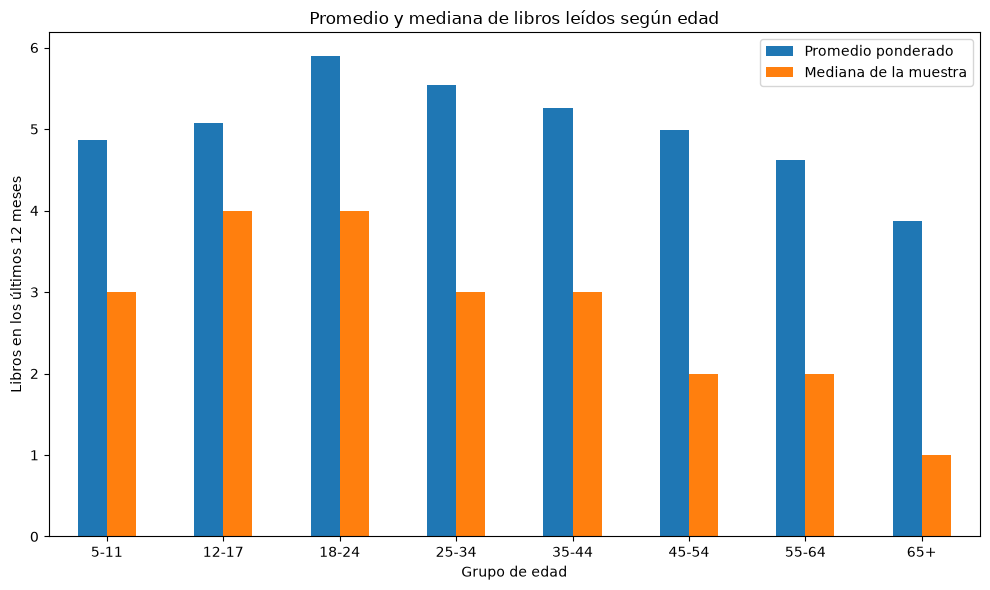

In [ ]:
import matplotlib.pyplot as plt

comparacion_edad[
    ["promedio_ponderado", "mediana_muestra"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Promedio y mediana de libros leídos según edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Libros en los últimos 12 meses")
plt.xticks(rotation=0)
plt.legend(["Promedio ponderado", "Mediana de la muestra"])
plt.tight_layout()
plt.show()

"los jóvenes tienen una mayor participación lectora, una mayor intensidad entre lectores, o ambas."

In [ ]:
participacion_edad = (
    base_analitica
    .groupby("grupo_edad", observed=False)
    .agg(
        muestra_total=("P5381", "size"),
        muestra_validos=("P5381_valido", "sum"),
        poblacion_total=("FEX_C", "sum"),
        poblacion_validos=(
            "FEX_C",
            lambda x: x[
                base_analitica.loc[x.index, "P5381_valido"]
            ].sum()
        )
    )
)

participacion_edad["pct_muestra_valida"] = (
    participacion_edad["muestra_validos"]
    / participacion_edad["muestra_total"]
    * 100
)

participacion_edad["pct_poblacion_valida"] = (
    participacion_edad["poblacion_validos"]
    / participacion_edad["poblacion_total"]
    * 100
)

participacion_edad

,muestra_total,muestra_validos,poblacion_total,poblacion_validos,pct_muestra_valida,pct_poblacion_valida
grupo_edad,,,,,,
5-11,12041,7862,5.988026e+06,3.823704e+06,65.293580,63.855842
12-17,10941,8647,4.876126e+06,3.888085e+06,79.032995,79.737189
18-24,13258,7856,5.837154e+06,3.279016e+06,59.254790,56.174901
25-34,16957,8569,7.283559e+06,3.537949e+06,50.533703,48.574457
35-44,14165,6704,6.107654e+06,2.957626e+06,47.327921,48.424900
45-54,12342,5634,5.274733e+06,2.291513e+06,45.649003,43.443208
55-64,9171,4430,3.765789e+06,1.783216e+06,48.304438,47.353062
65+,7567,3568,3.193071e+06,1.390058e+06,47.152108,43.533578


In [ ]:
for v in variables_xml:
    name = v.attrib.get("name", "")
    label = v.find("ddi:labl", ns)

    if label is not None:
        texto = " ".join((label.text or "").split()).lower()

        if (
            "últimos 12 meses" in texto
            and (
                "libro" in texto
                or "leyó" in texto
                or "leyeron" in texto
            )
        ):
            print(name, "→", label.text)

P1064S6 → 
        A qué ha ido ………. a la biblioteca en los últimos 12 meses:    a. Leer o consultar libros
      
P1852 → 
        En los últimos 12 meses ¿.leyó artículos o documentos académicos en medios digitales
      
P1853 → 
        En los últimos 12 meses ¿.leyó blogs o foros en internet
      
P1854 → 
        En los últimos 12 meses ¿.leyó correos electrónicos
      
P1851 → 
        En los últimos 12 meses ¿. leyó páginas Web:
      
P1855 → 
        En los últimos 12 meses ¿..leyó en redes sociales (Facebook, Twitter, Instagram, WhatsApp, etc.)
      
P1856 → 
        En los últimos 12 meses ¿.leyó noticias o artículos en medios digitales (revistas, periódicos, aplicaciones, etc.):
      
P1858 → 
        En los últimos 12 meses ¿.leyó libros digitales (total o parcialmente)
      
P1859 → 
        En los últimos 12 meses ¿..leyó documentos de trabajo en Internet
      
P1860 → 
        En los últimos 12 meses ¿..leyó periódicos impresos
      
P5388 → 
        En los últi

In [ ]:
print("P5380")
print(df["P5380"].value_counts(dropna=False).sort_index())

print("\nP1858")
print(df["P1858"].value_counts(dropna=False).sort_index())

P5380
P5380
1    50561
2    45881
Name: count, dtype: int64

P1858
P1858
1    15625
2    80817
Name: count, dtype: int64


In [ ]:
for variable in ["P5380", "P1858"]:
    v = next(
        x for x in variables_xml
        if x.attrib.get("name") == variable
    )

    print("\n", variable)
    print("Nombre:", v.attrib.get("name"))

    labl = v.find("ddi:labl", ns)
    print("Pregunta:", " ".join((labl.text or "").split()))

    for cat in v.findall(".//ddi:catgry", ns):
        code = cat.find("ddi:catValu", ns)
        label = cat.find("ddi:labl", ns)

        if code is not None:
            print(
                code.text,
                "→",
                " ".join((label.text or "").split())
                if label is not None else ""
            )


 P5380
Nombre: P5380
Pregunta: En los últimos 12 meses ¿.leyó libros impresos (total o parcialmente) (Nota: Para personas de 5 a 11 años, se tiene en cuenta si leyó o le leyeron)

          1
         → Sí

          2
         → No

 P1858
Nombre: P1858
Pregunta: En los últimos 12 meses ¿.leyó libros digitales (total o parcialmente)

          1
         → Sí

          2
         → No


In [ ]:
cruce_formatos = pd.crosstab(
    df["P5380"],
    df["P1858"],
    margins=True
)

cruce_formatos

P1858,1,2,All
P5380,,,
1,12916,37645,50561
2,2709,43172,45881
All,15625,80817,96442


In [ ]:
base_analitica = base_analitica.merge(
    df[
        llave_persona + ["P5380", "P1858"]
    ],
    on=llave_persona,
    how="left",
    validate="one_to_one"
)

In [ ]:
print(base_analitica.shape)
print(
    base_analitica[["P5380", "P1858"]]
    .isna()
    .sum()
)

(96442, 15)
P5380    0
P1858    0
dtype: int64


In [ ]:
base_analitica["lector_libro"] = (
    (base_analitica["P5380"] == 1)
    | (base_analitica["P1858"] == 1)
)

In [ ]:
participacion_edad = (
    base_analitica
    .groupby("grupo_edad", observed=False)
    .apply(
        lambda x: pd.Series({
            "tasa_lectora": np.average(
                x["lector_libro"],
                weights=x["FEX_C"]
            ),
            "muestra": len(x),
            "poblacion": x["FEX_C"].sum()
        })
    )
)

participacion_edad

,tasa_lectora,muestra,poblacion
grupo_edad,,,
5-11,0.638558,12041.0,5.988026e+06
12-17,0.797372,10941.0,4.876126e+06
18-24,0.561749,13258.0,5.837154e+06
25-34,0.485745,16957.0,7.283559e+06
35-44,0.484249,14165.0,6.107654e+06
45-54,0.434432,12342.0,5.274733e+06
55-64,0.473531,9171.0,3.765789e+06
65+,0.435336,7567.0,3.193071e+06


In [ ]:
resultado_edad = pd.DataFrame({
    "participacion_lectora": participacion_edad["tasa_lectora"] * 100,
    "intensidad_lectora": promedio_edad
})

resultado_edad

,participacion_lectora,intensidad_lectora
grupo_edad,,
5-11,63.855842,4.866013
12-17,79.737189,5.074498
18-24,56.174901,5.892535
25-34,48.574457,5.542438
35-44,48.424900,5.262498
45-54,43.443208,4.992434
55-64,47.353062,4.620604
65+,43.533578,3.876623


In [ ]:
pd.crosstab(
    base_analitica["lector_libro"],
    base_analitica["P5381_valido"],
    margins=True
)

P5381_valido,False,True,All
lector_libro,,,
False,43172,0,43172
True,0,53270,53270
All,43172,53270,96442


In [ ]:
# Libros estimados por persona de cada grupo de edad
resultado_agregado = (
    base_analitica
    .groupby("grupo_edad", observed=False)
    .apply(
        lambda x: pd.Series({
            "personas_estimadas": x["FEX_C"].sum(),
            "libros_estimados": (
                x.loc[x["universo_lectura"], "libros_12m"]
                * x.loc[x["universo_lectura"], "FEX_C"]
            ).sum()
        })
    )
)

resultado_agregado["libros_por_persona"] = (
    resultado_agregado["libros_estimados"]
    / resultado_agregado["personas_estimadas"]
)

resultado_agregado

,personas_estimadas,libros_estimados,libros_por_persona
grupo_edad,,,
5-11,5.988026e+06,1.860620e+07,3.107234
12-17,4.876126e+06,1.973008e+07,4.046262
18-24,5.837154e+06,1.932171e+07,3.310125
25-34,7.283559e+06,1.960886e+07,2.692209
35-44,6.107654e+06,1.556450e+07,2.548359
45-54,5.274733e+06,1.144023e+07,2.168873
55-64,3.765789e+06,8.239536e+06,2.187997
65+,3.193071e+06,5.388732e+06,1.687633


Gráfico 1 — Participación lectora por edad

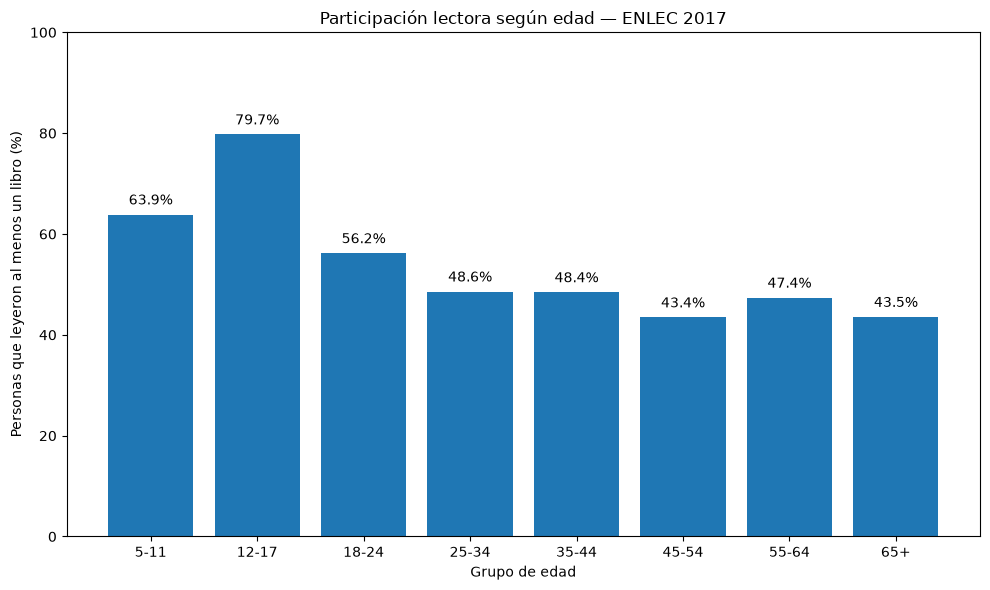

In [ ]:
# Datos
edades = [
    "5-11", "12-17", "18-24", "25-34",
    "35-44", "45-54", "55-64", "65+"
]

participacion = [
    63.855842, 79.737189, 56.174901, 48.574457,
    48.424900, 43.443208, 47.353062, 43.533578
]

# Gráfico
plt.figure(figsize=(10, 6))

plt.bar(edades, participacion)

plt.title("Participación lectora según edad — ENLEC 2017")
plt.xlabel("Grupo de edad")
plt.ylabel("Personas que leyeron al menos un libro (%)")
plt.ylim(0, 100)

# Etiquetas
for i, valor in enumerate(participacion):
    plt.text(
        i,
        valor + 2,
        f"{valor:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

Gráfico 2 — Libros por persona según edad

libros estimados por persona, incluyendo lectores y no lectores.

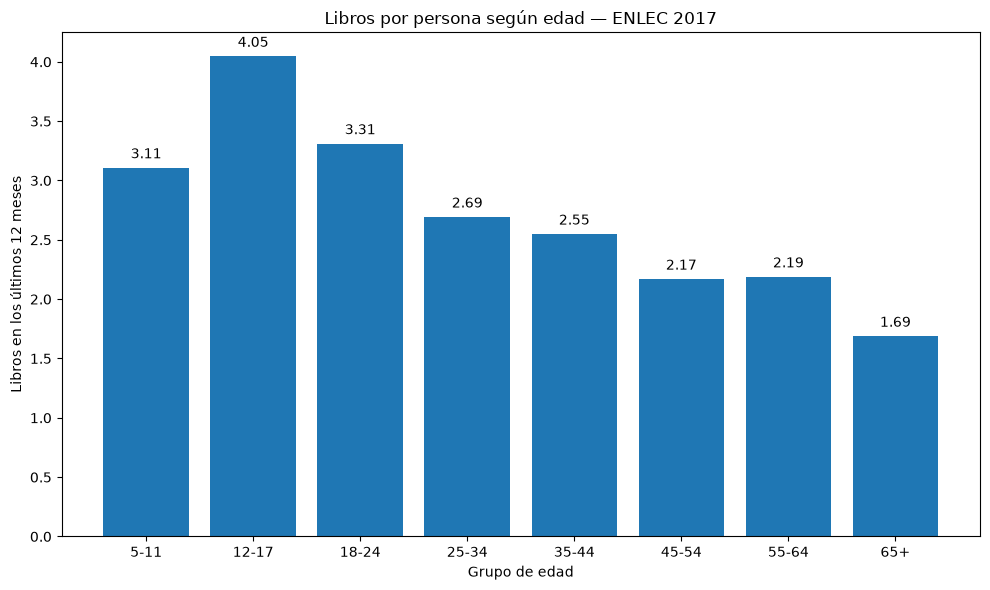

In [ ]:
libros_por_persona = [
    3.107234, 4.046262, 3.310125, 2.692209,
    2.548359, 2.168873, 2.187997, 1.687633
]

plt.figure(figsize=(10, 6))

plt.bar(edades, libros_por_persona)

plt.title("Libros por persona según edad — ENLEC 2017")
plt.xlabel("Grupo de edad")
plt.ylabel("Libros en los últimos 12 meses")

# Etiquetas
for i, valor in enumerate(libros_por_persona):
    plt.text(
        i,
        valor + 0.08,
        f"{valor:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 1. INSPECCIÓN DE VARIABLES EDUCATIVAS
# ============================================================

variables_educacion = ["P260", "P261", "P6170"]

for variable in variables_educacion:
    print("\n" + "="*60)
    print(variable)
    print("="*60)

    print("Valores:")
    print(
        df_personas[variable]
        .value_counts(dropna=False)
        .sort_index()
        .to_string()
    )


P260
Valores:
P260
0     10206
1      4331
2     26114
3     17289
4     19681
5      4489
6       261
7      7017
8      3446
9     12563
10     2199
11      698
12       89

P261
Valores:
P261
1.0      8457
2.0     12808
3.0     11221
4.0      5100
5.0     17786
6.0      5376
7.0      4405
8.0      4208
9.0      4385
10.0     3033
11.0    21209
12.0       50
13.0      139
inf     10206

P6170
Valores:
P6170
1    33288
2    75095


In [ ]:
# ============================================================
# 2. EXTRAER ETIQUETAS DE P260, P261 Y P6170 DESDE EL XML
# ============================================================

import xml.etree.ElementTree as ET

tree = ET.parse(archivo_diccionario)
root = tree.getroot()

ns = {"ddi": "http://www.icpsr.umich.edu/DDI"}

for variable_buscada in variables_educacion:

    print("\n" + "="*70)
    print(variable_buscada)
    print("="*70)

    encontrados = []

    for var in root.findall(".//ddi:dataDscr/ddi:var", ns):

        if var.attrib.get("name") == variable_buscada:
            encontrados.append(var)

    if not encontrados:
        print("No encontrada en el XML")
        continue

    var = encontrados[0]

    print("VARNAME:", var.attrib.get("name"))
    print("ID:", var.attrib.get("ID"))

    label = var.find("ddi:labl", ns)
    if label is not None:
        print("LABEL:", label.text)

    print("\nCATEGORÍAS:")

    for cat in var.findall(".//ddi:catgry", ns):

        cat_number = cat.find("ddi:catValu", ns)
        cat_label = cat.find("ddi:labl", ns)

        numero = cat_number.text if cat_number is not None else ""
        etiqueta = cat_label.text if cat_label is not None else ""

        print(f"{numero} → {etiqueta}")


P260
VARNAME: P260
ID: V304
LABEL: 
        ¿Cuál es el nivel educativo más alto alcanzado por .... y el último año o grado aprobado en este nivel?
      

CATEGORÍAS:

          1
         → 
          Preescolar
        

          2
         → 
          Básica primaria
        

          3
         → 
          Básica secundaria (Bachillerato básico)
        

          4
         → 
          Media académica o clásica (Bachillerato clásico)
        

          5
         → 
          Media técnica (Bachillerato técnico)
        

          6
         → 
          Normalista
        

          7
         → 
          Técnica Profesional
        

          8
         → 
          Tecnológica
        

          9
         → 
          Universitario
        

          10
         → 
          Especialización
        

          11
         → 
          Maestría
        

          12
         → 
          Doctorado
        

          13
         → 
          Ninguna
        

P

In [ ]:
# Personas con P260 = 0
p260_cero = df_personas[df_personas["P260"] == 0].copy()

print("Total P260 = 0:", len(p260_cero))

print("\nDistribución por edad:")
print(
    p260_cero["P5785"]
    .value_counts()
    .sort_index()
    .head(30)
)

Total P260 = 0: 10206

Distribución por edad:
P5785
0     1456
1     1495
2     1324
3     1108
4      882
5      324
6       78
7       36
8       19
9       14
10       9
11      25
12      10
13      10
14      12
15      10
16      14
17       6
18       8
19      13
20      13
21       8
22      20
23      15
24      27
25      12
26      15
27      17
28      18
29      14
Name: count, dtype: int64


In [ ]:
print("\nP260 según asistencia educativa:")
print(
    pd.crosstab(
        p260_cero["P260"],
        p260_cero["P6170"]
    )
)

print("\nDistribución de P261:")
print(
    p260_cero["P261"]
    .value_counts(dropna=False)
    .sort_index()
)


P260 según asistencia educativa:
P6170     1     2
P260             
0      1059  9147

Distribución de P261:
P261
inf    10206
Name: count, dtype: int64


In [ ]:
# ============================================================
# DISTRIBUCIÓN DE NIVEL EDUCATIVO VÁLIDO
# ============================================================

educacion_validos = df_personas[
    (df_personas["P5785"] >= 5) &
    (df_personas["P260"].between(1, 13))
].copy()

print("Personas de 5+:", (df_personas["P5785"] >= 5).sum())
print("Con P260 válido:", len(educacion_validos))
print(
    "P260 no válido entre 5+:",
    ((df_personas["P5785"] >= 5) &
     (~df_personas["P260"].between(1, 13))).sum()
)

print("\nDistribución P260:")
print(
    educacion_validos["P260"]
    .value_counts()
    .sort_index()
)

Personas de 5+: 100606
Con P260 válido: 96665
P260 no válido entre 5+: 3941

Distribución P260:
P260
1      2819
2     26114
3     17289
4     19681
5      4489
6       261
7      7017
8      3446
9     12563
10     2199
11      698
12       89
Name: count, dtype: int64


In [ ]:
# ============================================================
# P260 SEGÚN EDAD
# ============================================================

tabla_edad_educacion = pd.crosstab(
    pd.cut(
        educacion_validos["P5785"],
        bins=[5, 12, 18, 25, 35, 45, 55, 65, 200],
        labels=[
            "5-11",
            "12-17",
            "18-24",
            "25-34",
            "35-44",
            "45-54",
            "55-64",
            "65+"
        ],
        right=False
    ),
    educacion_validos["P260"]
)

print(tabla_edad_educacion)

P260     1     2     3     4     5   6     7     8     9    10   11  12
P5785                                                                  
5-11   2748  8483   305     0     0   0     0     0     0    0    0   0
12-17    11  1769  7036  1604   371   2    50    19   146    0    0   0
18-24     4   437  1822  4355  1171  55  1477   812  3120   34    5   0
25-34    10  1287  1775  4739  1108  52  2403  1124  3791  535  191  16
35-44     6  2434  1873  3731   791  32  1560   706  2275  604  207  28
45-54    11  3596  2068  2775   540  36   895   446  1506  446  142  16
55-64    10  3564  1534  1588   300  37   453   250  1100  369   97  14
65+      19  4544   876   889   208  47   179    89   625  211   56  15


In [ ]:
# ============================================================
# 1. INCORPORAR NIVEL EDUCATIVO A LA BASE ANALÍTICA
# ============================================================

base_analitica = base_analitica.merge(
    df_personas[
        llave_persona + ["P260", "P261", "P6170"]
    ],
    on=llave_persona,
    how="left",
    validate="one_to_one"
)

# Verificación
print(base_analitica.shape)
print("\nValores faltantes:")
print(
    base_analitica[["P260", "P261", "P6170"]]
    .isna()
    .sum()
)

(96442, 19)

Valores faltantes:
P260     0
P261     0
P6170    0
dtype: int64


In [ ]:
# ============================================================
# 2. CREAR GRUPOS EDUCATIVOS
# ============================================================

def clasificar_educacion(x):
    if x == 1:
        return "Preescolar"
    elif x == 2:
        return "Primaria"
    elif x == 3:
        return "Secundaria"
    elif x in [4, 5, 6]:
        return "Media"
    elif x in [7, 8, 9, 10, 11, 12]:
        return "Superior"
    elif x == 13:
        return "Ninguna"
    else:
        return np.nan


base_analitica["grupo_educativo"] = (
    base_analitica["P260"]
    .apply(clasificar_educacion)
)

print(
    base_analitica["grupo_educativo"]
    .value_counts(dropna=False)
)

grupo_educativo
Superior      26010
Primaria      25077
Media         24430
Secundaria    17281
Preescolar     2764
NaN             880
Name: count, dtype: int64


In [ ]:
# ============================================================
# 3. PARTICIPACIÓN LECTORA SEGÚN EDUCACIÓN
# ============================================================

def promedio_ponderado(grupo):
    valido = grupo["P5381_valido"]

    return (
        grupo.loc[valido, "FEX_C"].sum()
        /
        grupo["FEX_C"].sum()
        * 100
    )


participacion_educacion = (
    base_analitica
    .dropna(subset=["grupo_educativo"])
    .groupby("grupo_educativo", observed=True)
    .apply(promedio_ponderado)
)

print(participacion_educacion)

grupo_educativo
Media         47.478296
Preescolar    40.624960
Primaria      49.132020
Secundaria    54.280019
Superior      71.476666
dtype: float64


In [ ]:
# ============================================================
# 4. LIBROS ENTRE QUIENES LEEN
# ============================================================

intensidad_educacion = (
    base_analitica[
        base_analitica["universo_lectura"] &
        base_analitica["grupo_educativo"].notna()
    ]
    .groupby("grupo_educativo", observed=True)
    .apply(
        lambda g: np.average(
            g["libros_12m"],
            weights=g["FEX_C"]
        )
    )
)

print(intensidad_educacion)

grupo_educativo
Media         4.512479
Preescolar    4.853247
Primaria      3.830205
Secundaria    4.250210
Superior      7.380441
dtype: float64


In [ ]:
# ============================================================
# 5. LIBROS POR PERSONA DEL GRUPO
# ============================================================

libros_por_persona_educacion = (
    base_analitica[
        base_analitica["grupo_educativo"].notna()
    ]
    .groupby("grupo_educativo", observed=True)
    .apply(
        lambda g: (
            np.sum(
                g.loc[g["universo_lectura"], "FEX_C"] *
                g.loc[g["universo_lectura"], "libros_12m"]
            )
            /
            g["FEX_C"].sum()
        )
    )
)

print(libros_por_persona_educacion)

grupo_educativo
Media         2.142448
Preescolar    1.971630
Primaria      1.881857
Secundaria    2.307015
Superior      5.275293
dtype: float64


In [ ]:
# ============================================================
# 12-17 AÑOS: DISTRIBUCIÓN EDUCATIVA
# ============================================================

adolescentes = base_analitica[
    (base_analitica["edad"] >= 12) &
    (base_analitica["edad"] < 18) &
    (base_analitica["grupo_educativo"].notna())
].copy()

print("Total adolescentes con educación válida:", len(adolescentes))

print("\nDistribución:")
print(
    adolescentes["grupo_educativo"]
    .value_counts()
)

Total adolescentes con educación válida: 10937

Distribución:
grupo_educativo
Secundaria    7033
Media         1977
Primaria      1706
Superior       215
Preescolar       6
Name: count, dtype: int64


In [ ]:
# ============================================================
# 12-17: LECTURA SEGÚN EDUCACIÓN
# ============================================================

def participacion_ponderada(g):
    return (
        g.loc[g["universo_lectura"], "FEX_C"].sum()
        /
        g["FEX_C"].sum()
        * 100
    )

def intensidad_ponderada(g):
    lectores = g[g["universo_lectura"]]

    return np.average(
        lectores["libros_12m"],
        weights=lectores["FEX_C"]
    )

def libros_por_persona(g):
    libros = (
        g.loc[g["universo_lectura"], "FEX_C"]
        *
        g.loc[g["universo_lectura"], "libros_12m"]
    ).sum()

    poblacion = g["FEX_C"].sum()

    return libros / poblacion


resultados_12_17 = (
    adolescentes
    .groupby("grupo_educativo", observed=True)
    .apply(
        lambda g: pd.Series({
            "participacion_%": participacion_ponderada(g),
            "libros_entre_lectores": intensidad_ponderada(g),
            "libros_por_persona": libros_por_persona(g),
            "muestra": len(g),
            "poblacion_estimada": g["FEX_C"].sum()
        })
    )
)

print(resultados_12_17)

                 participacion_%  libros_entre_lectores  libros_por_persona  \
grupo_educativo                                                               
Media                  88.211993               6.079131            5.362523   
Preescolar             13.392994               2.244898            0.300659   
Primaria               67.867088               4.140475            2.810020   
Secundaria             80.965753               4.975383            4.028356   
Superior               96.106534               6.846876            6.580296   

                 muestra  poblacion_estimada  
grupo_educativo                               
Media             1977.0        8.212204e+05  
Preescolar           6.0        4.655384e+03  
Primaria          1706.0        9.747192e+05  
Secundaria        7033.0        2.997357e+06  
Superior           215.0        7.772700e+04  


In [ ]:
# ============================================================
# 12-17: ASISTENCIA EDUCATIVA
# ============================================================

print(
    pd.crosstab(
        adolescentes["grupo_educativo"],
        adolescentes["P6170"],
        margins=True
    )
)

P6170               1     2    All
grupo_educativo                   
Media            1718   259   1977
Preescolar          3     3      6
Primaria         1435   271   1706
Secundaria       6340   693   7033
Superior          199    16    215
All              9695  1242  10937


In [ ]:
# ============================================================
# 12-17: LECTURA SEGÚN ASISTENCIA EDUCATIVA
# ============================================================

asistencia_12_17 = (
    adolescentes
    .groupby("P6170", observed=True)
    .apply(
        lambda g: pd.Series({
            "participacion_%": participacion_ponderada(g),
            "libros_entre_lectores": intensidad_ponderada(g),
            "libros_por_persona": libros_por_persona(g),
            "muestra": len(g),
            "poblacion_estimada": g["FEX_C"].sum()
        })
    )
)

print(asistencia_12_17)

       participacion_%  libros_entre_lectores  libros_por_persona  muestra  \
P6170                                                                        
1            85.252746               5.145279            4.386491   9695.0   
2            45.628621               4.255415            1.941687   1242.0   

       poblacion_estimada  
P6170                      
1            4.197898e+06  
2            6.777814e+05  


In [ ]:
# ============================================================
# 12-17: GRADO APROBADO
# ============================================================

print(
    adolescentes["P261"]
    .value_counts()
    .sort_index()
)

P261
1.0      182
2.0       66
3.0      148
4.0      352
5.0     1179
6.0     1989
7.0     1920
8.0     1713
9.0     1411
10.0    1321
11.0     655
12.0       1
Name: count, dtype: int64


In [ ]:
# ============================================================
# 12-17: LECTURA SEGÚN GRADO APROBADO
# ============================================================

lectura_por_grado = (
    adolescentes[
        adolescentes["P261"].between(1, 13)
    ]
    .groupby("P261")
    .apply(
        lambda g: pd.Series({
            "participacion_%": participacion_ponderada(g),
            "libros_entre_lectores": intensidad_ponderada(g),
            "libros_por_persona": libros_por_persona(g),
            "muestra": len(g),
            "poblacion_estimada": g["FEX_C"].sum()
        })
    )
)

print(lectura_por_grado)

      participacion_%  libros_entre_lectores  libros_por_persona  muestra  \
P261                                                                        
1.0         91.063648               6.668822            6.072872    182.0   
2.0         82.256930               6.943419            5.711444     66.0   
3.0         65.772433               3.444008            2.265208    148.0   
4.0         67.294963               4.287419            2.885217    352.0   
5.0         68.279164               4.140127            2.826844   1179.0   
6.0         78.324468               4.923987            3.856687   1989.0   
7.0         80.479640               4.789356            3.854457   1920.0   
8.0         80.792228               4.895770            3.955401   1713.0   
9.0         85.930402               5.397462            4.638061   1411.0   
10.0        91.167152               6.053867            5.519138   1321.0   
11.0        82.910775               6.129223            5.081786    655.0   

In [ ]:
# ============================================================
# 12-17: GRADO APROBADO ENTRE QUIENES ACTUALMENTE ESTUDIAN
# ============================================================

estudian_12_17 = adolescentes[
    (adolescentes["P6170"] == 1) &
    (adolescentes["P261"].between(1, 12))
].copy()

lectura_grado_estudian = (
    estudian_12_17
    .groupby("P261")
    .apply(
        lambda g: pd.Series({
            "participacion_%": participacion_ponderada(g),
            "libros_entre_lectores": intensidad_ponderada(g),
            "libros_por_persona": libros_por_persona(g),
            "muestra": len(g),
            "poblacion_estimada": g["FEX_C"].sum()
        })
    )
)

print(lectura_grado_estudian)

      participacion_%  libros_entre_lectores  libros_por_persona  muestra  \
P261                                                                        
1.0         95.335272               6.843315            6.524093    169.0   
2.0         96.946545               7.094025            6.877412     52.0   
3.0         79.555621               3.633890            2.890963    118.0   
4.0         71.474477               4.422615            3.161041    305.0   
5.0         79.250658               4.179387            3.312192    993.0   
6.0         82.187511               4.994474            4.104834   1761.0   
7.0         84.892631               4.786442            4.063337   1748.0   
8.0         86.203096               5.008691            4.317647   1558.0   
9.0         90.152752               5.345224            4.818867   1273.0   
10.0        91.800822               6.096723            5.596842   1251.0   
11.0        92.060915               6.753903            6.217705    466.0   

In [ ]:
# ============================================================
# EDAD POR GRADO ENTRE QUIENES ESTUDIAN
# ============================================================

print(
    estudian_12_17
    .groupby("P261")["edad"]
    .agg(["count", "mean", "min", "max"])
)

      count       mean  min  max
P261                            
1.0     169  16.727811   12   17
2.0      52  15.038462   12   17
3.0     118  12.966102   12   17
4.0     305  12.655738   12   17
5.0     993  12.854985   12   17
6.0    1761  13.162976   12   17
7.0    1748  13.844394   12   17
8.0    1558  14.716945   12   17
9.0    1273  15.485467   12   17
10.0   1251  16.211831   12   17
11.0    466  16.624464   14   17
12.0      1  17.000000   17   17


1. Tabla de lectura por edad y grado

In [ ]:
# ============================================================
# 12-17: MISMA EDAD, DISTINTO GRADO
# ============================================================

estudian_12_17 = adolescentes[
    (adolescentes["P6170"] == 1) &
    (adolescentes["P261"].between(5, 11))
].copy()

tabla_edad_grado = (
    estudian_12_17
    .groupby(["edad", "P261"])
    .apply(
        lambda g: pd.Series({
            "participacion_%": participacion_ponderada(g),
            "libros_entre_lectores": intensidad_ponderada(g),
            "libros_por_persona": libros_por_persona(g),
            "muestra": len(g),
            "poblacion_estimada": g["FEX_C"].sum()
        })
    )
)

print(tabla_edad_grado.to_string())

           participacion_%  libros_entre_lectores  libros_por_persona  muestra  poblacion_estimada
edad P261                                                                                         
12   5.0         83.754651               4.465904            3.740402    524.0       238392.840500
     6.0         89.559795               5.319420            4.764061    691.0       273011.980841
     7.0         85.180439               4.800087            4.088735    230.0        80683.675738
     8.0         88.912600               3.739682            3.325048     28.0         8348.909705
     9.0         86.264729               2.000000            1.725295      2.0          115.571029
     10.0       100.000000              12.000000           12.000000      1.0          369.238970
13   5.0         85.120801               4.124828            3.511087    240.0       112637.615005
     6.0         83.048761               4.740251            3.936720    532.0       244681.464818
     7.0  

2. Y hagamos una versión más sencilla para detectar rápidamente el patrón

In [ ]:
tabla_participacion_edad_grado = (
    estudian_12_17
    .groupby(["edad", "P261"])
    .apply(participacion_ponderada)
    .unstack()
)

print(
    tabla_participacion_edad_grado.round(1)
)

P261  5.0   6.0   7.0   8.0   9.0    10.0   11.0
edad                                            
12    83.8  89.6  85.2  88.9  86.3  100.0    NaN
13    85.1  83.0  91.0  90.4  90.6  100.0    NaN
14    73.5  78.8  86.6  89.4  97.2   94.8  100.0
15    69.9  68.4  77.0  86.4  94.9   92.3   79.9
16    44.3  76.1  78.0  79.7  87.9   91.9   85.8
17    66.8  72.4  74.4  79.5  80.7   91.4   94.4


3. Especialmente quiero mirar los 15 años

In [ ]:
# ============================================================
# 15 AÑOS: LECTURA SEGÚN GRADO
# ============================================================

quince = estudian_12_17[
    estudian_12_17["edad"] == 15
].copy()

resultado_15 = (
    quince[
        quince["P261"].between(5, 11)
    ]
    .groupby("P261")
    .apply(
        lambda g: pd.Series({
            "participacion_%": participacion_ponderada(g),
            "libros_entre_lectores": intensidad_ponderada(g),
            "libros_por_persona": libros_por_persona(g),
            "muestra": len(g),
            "poblacion_estimada": g["FEX_C"].sum()
        })
    )
)

print(resultado_15)

      participacion_%  libros_entre_lectores  libros_por_persona  muestra  \
P261                                                                        
5.0         69.918871               4.266971            2.983418     61.0   
6.0         68.448928               4.729475            3.237275    163.0   
7.0         77.045827               4.325642            3.332727    261.0   
8.0         86.359701               4.893023            4.225600    437.0   
9.0         94.897123               5.773813            5.479183    436.0   
10.0        92.335136               5.429041            5.012912    200.0   
11.0        79.947121               2.653777            2.121618     15.0   

      poblacion_estimada  
P261                      
5.0         38938.149115  
6.0        103931.341514  
7.0        114339.082730  
8.0        184475.246594  
9.0        180765.209729  
10.0        75213.444445  
11.0         4371.700580  
